# Water Quality Analysis — Location vs No-Location Ponds

This notebook merges the water quality data with the pond locations key and repeats every analysis from `water_quality_analysis.ipynb`, breaking each result down by whether a pond has a known location (coordinates and/or village) or not (`no_location`).

**`no_location = True`** — the pond has **neither** GPS coordinates **nor** a village name in the location CSV.
**`no_location = False`** — the pond has at least one of: latitude/longitude, village name.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")

# ── Load raw data ─────────────────────────────────────────────────────────────
wq  = pd.read_csv('data/water_quality.csv')
loc = pd.read_csv('data/Shared_ 2026 Github ARA Pond IDs Key.csv')

# ── Coerce location numeric fields ────────────────────────────────────────────
loc['latitude']  = pd.to_numeric(loc['latitude'],  errors='coerce')
loc['longitude'] = pd.to_numeric(loc['longitude'], errors='coerce')

# ── Identify no-location ponds in the location CSV ───────────────────────────
loc['_has_coords']  = loc['latitude'].notna() & loc['longitude'].notna()
loc['_has_village'] = loc['village'].notna() & loc['village'].astype(str).str.strip().ne('')
loc['no_location']  = ~(loc['_has_coords'] | loc['_has_village'])

# Keep only the columns we need for the merge
loc_slim = loc[['public_pond_id', 'village', 'latitude', 'longitude', 'no_location']].copy()

# ── Merge: water quality left-join location key ───────────────────────────────
df = wq.merge(loc_slim, left_on='pond_id', right_on='public_pond_id', how='left')

# Ponds entirely absent from the location CSV get no_location = True
df['no_location'] = df['no_location'].fillna(True)

# Readable label for plots
df['location_group'] = df['no_location'].map({False: 'Has location', True: 'No location'})

# Palette used throughout
LOC_PALETTE = {'Has location': 'steelblue', 'No location': 'coral'}

print(f"Total rows         : {len(df):,}")
print(f"Unique ponds       : {df['pond_id'].nunique()}")
print(f"'Has location' obs : {(~df['no_location']).sum():,}  "
      f"({(~df['no_location']).mean()*100:.1f}%)")
print(f"'No location'  obs : {df['no_location'].sum():,}  "
      f"({df['no_location'].mean()*100:.1f}%)")
print(f"\nPonds by group:")
print(df.groupby('location_group')['pond_id'].nunique().rename('unique_ponds'))
df.head(3)

Total rows         : 11,433
Unique ponds       : 298
'Has location' obs : 9,932  (86.9%)
'No location'  obs : 1,501  (13.1%)

Ponds by group:
location_group
Has location    251
No location      47
Name: unique_ponds, dtype: int64


,Sr. No,Date of data collection,Time of data collection,pond_id,region,Type,Is follow up,Is follow up possible,Reason follow up not possible,Group,...,Species,Weight,Notes,Have fish been helped,public_pond_id,village,latitude,longitude,no_location,location_group
0,12335,01/27/2026,16:05,pond_5f07dc7a,Eluru,Evening,No,NaN,NaN,Regular ara pond,...,"Rohu (Labeo rohita), Catla (Catla catla)",100.0,NaN,No,pond_5f07dc7a,Ponangi,16.648841,81.100042,False,Has location
1,12329,01/27/2026,15:53,pond_0c63298a,Eluru,Evening,No,NaN,NaN,Regular ara pond,...,"Catla (Catla catla), Rohu (Labeo rohita)",NaN,NaN,No,pond_0c63298a,Sreeparru,16.635835,81.146332,False,Has location
2,12334,01/27/2026,15:50,pond_44865e41,Eluru,Evening,No,NaN,NaN,Regular ara pond,...,"Rohu (Labeo rohita), Catla (Catla catla)",30.0,NaN,No,pond_44865e41,Ponangi,16.654390,81.104532,False,Has location


## Data Overview and Cleaning

In [9]:
numeric_cols = [
    'DO (mg/L)', 'pH', 'Temp (in °C)',
    'Ammonia—TAN (NH3-N) (mg/L)', 'Ammonia—NH3 (mg/L)',
    'Feed amount (kg)', 'Stocking density (per acre)', 'Weight'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("=== Summary statistics by location group ===\n")
for grp, sub in df.groupby('location_group'):
    print(f"--- {grp} (n={len(sub):,} rows, {sub['pond_id'].nunique()} ponds) ---")
    print(sub[[c for c in numeric_cols if c in sub.columns]].describe().round(2))
    print()

=== Summary statistics by location group ===

--- Has location (n=9,932 rows, 251 ponds) ---
       DO (mg/L)       pH  Temp (in °C)  Ammonia—TAN (NH3-N) (mg/L)  \
count    9919.00  9918.00       9913.00                     4662.00   
mean        6.60     8.20         29.46                        0.18   
std         3.47     0.27          2.64                        0.19   
min         0.00     5.52         21.40                        0.00   
25%         3.50     8.03         27.50                        0.04   
50%         4.70     8.23         29.70                        0.14   
75%         9.80     8.39         31.20                        0.26   
max        27.10     9.78         37.90                        3.00   

       Ammonia—NH3 (mg/L)  Feed amount (kg)  Stocking density (per acre)  \
count              841.00           5400.00                      8117.00   
mean                 0.02            526.57                      8514.79   
std                  0.02            57

## Visualizing Distributions
Histograms of key water quality parameters, with `Has location` and `No location` ponds overlaid using `hue`.

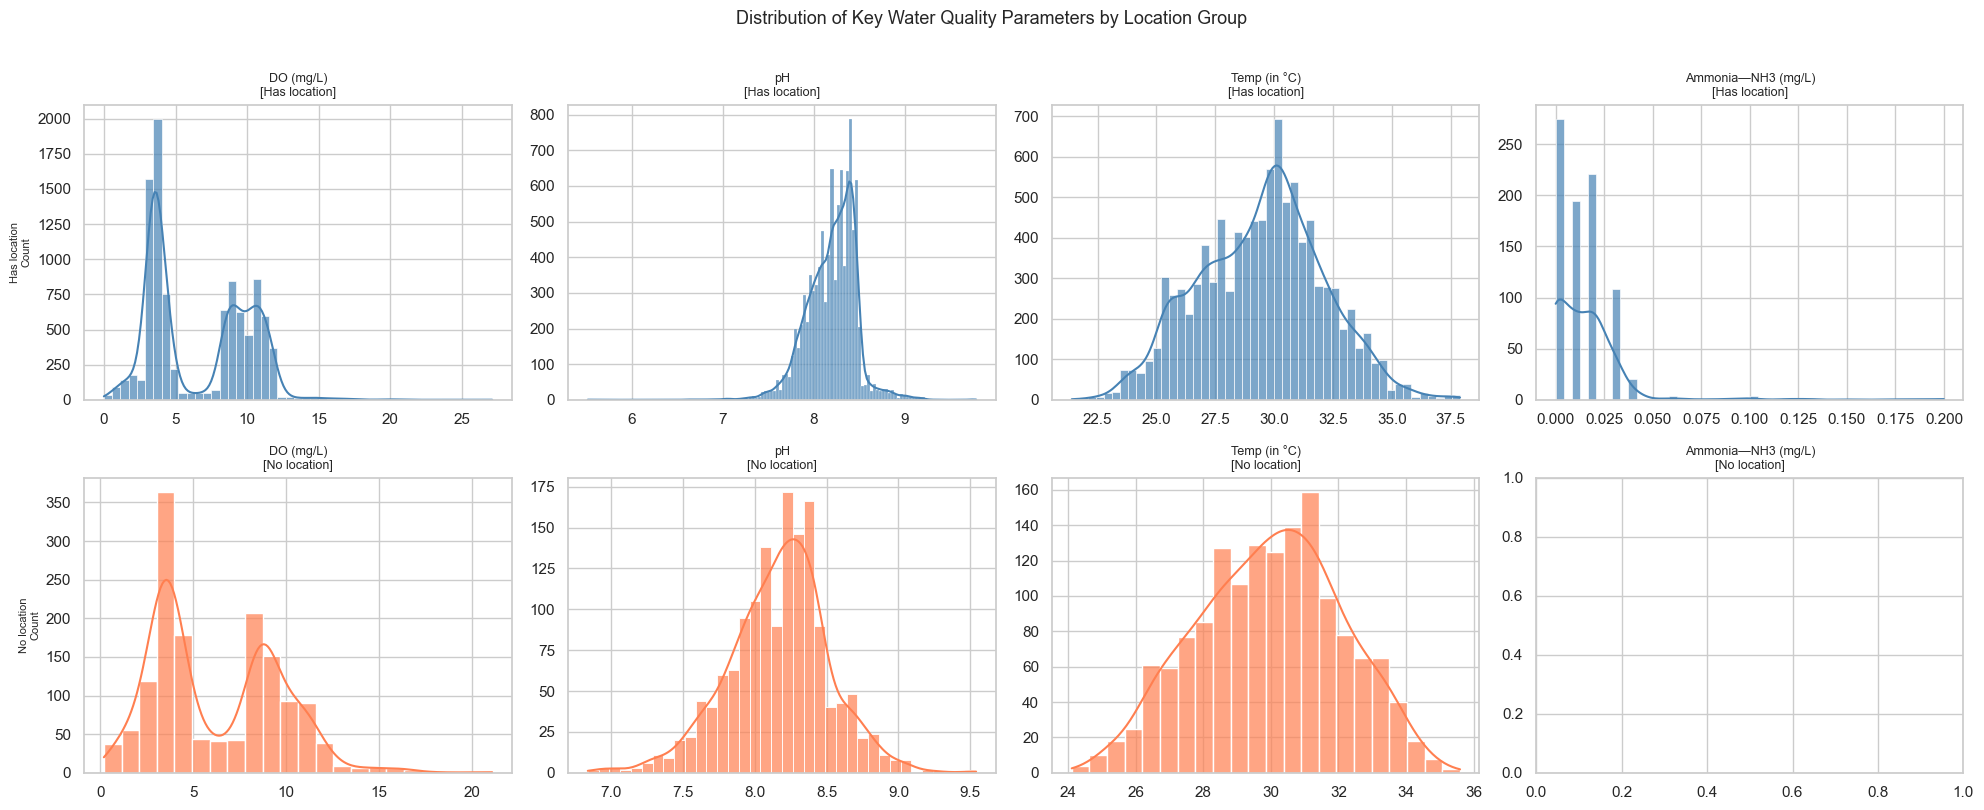

In [10]:
cols_to_plot = ['DO (mg/L)', 'pH', 'Temp (in °C)', 'Ammonia—NH3 (mg/L)']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col_i, col in enumerate(cols_to_plot):
    # Top row: Has location | Bottom row: No location
    for row_i, (grp, sub) in enumerate(df.groupby('location_group')):
        ax = axes[row_i, col_i]
        color = LOC_PALETTE[grp]
        sns.histplot(sub[col].dropna(), kde=True, color=color, ax=ax, alpha=0.7)
        ax.set_title(f'{col}\n[{grp}]', fontsize=9)
        ax.set_xlabel('')
        if col_i == 0:
            ax.set_ylabel(f'{grp}\nCount', fontsize=8)
        else:
            ax.set_ylabel('')

plt.suptitle('Distribution of Key Water Quality Parameters by Location Group', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Correlation Analysis
Separate heatmaps for `Has location` and `No location` ponds so the correlation structures can be compared directly.

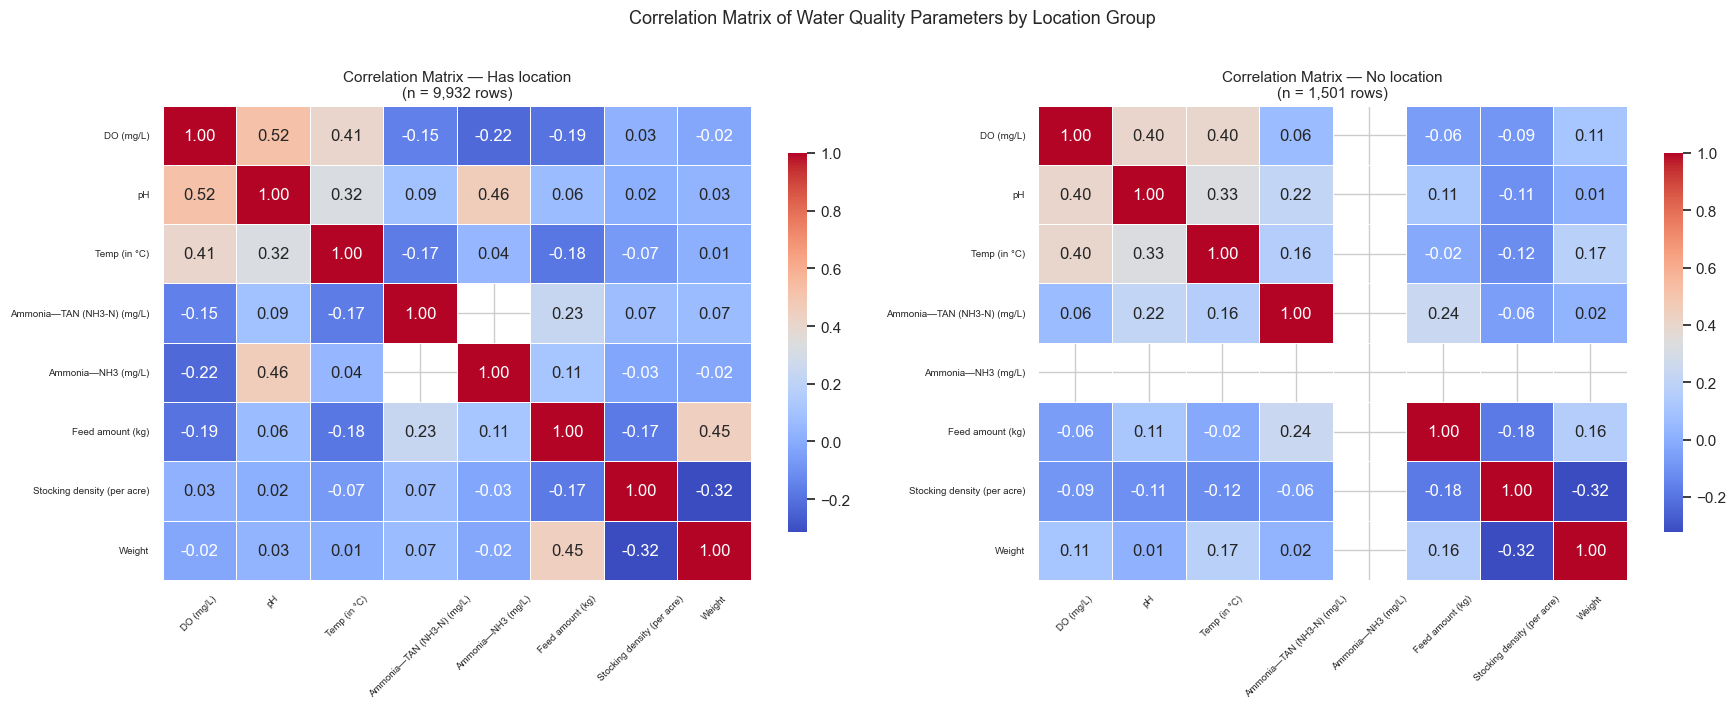

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (grp, sub) in zip(axes, df.groupby('location_group')):
    corr = sub[[c for c in numeric_cols if c in sub.columns]].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'Correlation Matrix — {grp}\n(n = {len(sub):,} rows)', fontsize=11)
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7, rotation=0)

plt.suptitle('Correlation Matrix of Water Quality Parameters by Location Group', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Comparing Regions
Dissolved Oxygen levels by region, grouped further by `location_group` using `hue`.

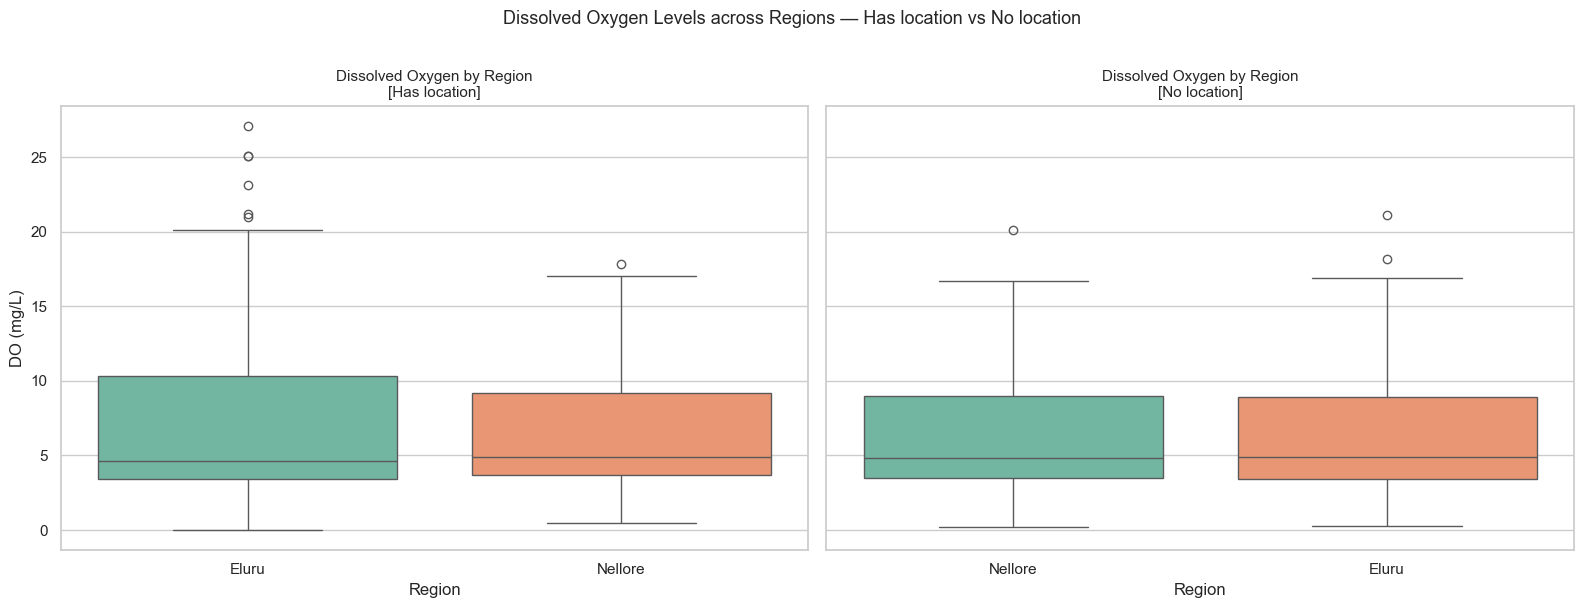

In [12]:
if 'region' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, (grp, sub) in zip(axes, df.groupby('location_group')):
        color = LOC_PALETTE[grp]
        sns.boxplot(x='region', y='DO (mg/L)', data=sub,
                    hue='region', palette='Set2', legend=False, ax=ax)
        ax.set_title(f'Dissolved Oxygen by Region\n[{grp}]', fontsize=11)
        ax.set_xlabel('Region')
        ax.set_ylabel('DO (mg/L)')

    plt.suptitle('Dissolved Oxygen Levels across Regions — Has location vs No location',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# Pond Measurement Frequency Analysis (Morning Only)

This section repeats the 15-part frequency analysis from `water_quality_analysis.ipynb`, with every chart broken down by **`location_group`** (`Has location` vs `No location`).

> **Regularity definition:** CV = σ / μ of inter-measurement gaps. Lower CV = more regular scheduling.

In [13]:
# ── Filter to morning observations, carry location_group through ──────────────
morning = df[df['Type'].str.lower() == 'morning'].copy()
morning['date'] = pd.to_datetime(morning['Date of data collection'], format='%m/%d/%Y')
morning = morning.drop_duplicates(subset=['date', 'pond_id'])

morning['year']    = morning['date'].dt.year
morning['month']   = morning['date'].dt.to_period('M')
morning['quarter'] = morning['date'].dt.to_period('Q')

# ── Gap computation ────────────────────────────────────────────────────────────
morning_s = morning.sort_values(['pond_id', 'date'])
morning_s['gap_days'] = morning_s.groupby('pond_id')['date'].diff().dt.days
gaps = morning_s.dropna(subset=['gap_days']).copy()

# ── Per-pond summary (includes location_group) ─────────────────────────────────
def pond_stats(g):
    g_gaps = g['gap_days'].dropna()
    return pd.Series({
        'n_obs':      len(g),
        'first_date': g['date'].min(),
        'last_date':  g['date'].max(),
        'span_days':  (g['date'].max() - g['date'].min()).days,
        'mean_gap':   g_gaps.mean()   if len(g_gaps) else np.nan,
        'median_gap': g_gaps.median() if len(g_gaps) else np.nan,
        'std_gap':    g_gaps.std()    if len(g_gaps) else np.nan,
        'max_gap':    g_gaps.max()    if len(g_gaps) else np.nan,
        'min_gap':    g_gaps.min()    if len(g_gaps) else np.nan,
        'cv_gap':     (g_gaps.std() / g_gaps.mean())
                      if (len(g_gaps) >= 2 and g_gaps.mean() > 0) else np.nan,
        'location_group': g['location_group'].iloc[0],
    })

pond_summary = (morning_s.groupby('pond_id')
                .apply(pond_stats, include_groups=False)
                .reset_index())

print(f"Morning observations : {len(morning):,}")
print(f"Unique ponds         : {morning['pond_id'].nunique()}")
print(f"Date range           : {morning['date'].min().date()} → {morning['date'].max().date()}")
print()
print("Morning obs by location group:")
print(morning.groupby('location_group').agg(
    rows=('pond_id','count'), unique_ponds=('pond_id','nunique')))
print()
print("Gap summary (all ponds):")
print(gaps['gap_days'].describe().round(1))

Morning observations : 5,904
Unique ponds         : 298
Date range           : 2021-06-19 → 2026-01-27

Morning obs by location group:
                rows  unique_ponds
location_group                    
Has location    5140           251
No location      764            47

Gap summary (all ponds):
count    5606.0
mean       28.6
std        41.5
min         1.0
25%        14.0
50%        23.0
75%        32.0
max      1158.0
Name: gap_days, dtype: float64


## Analysis 1 — Distribution of Inter-Measurement Gaps

Separate rows of plots for `Has location` (top) and `No location` (bottom), so the gap distribution shapes can be compared directly.

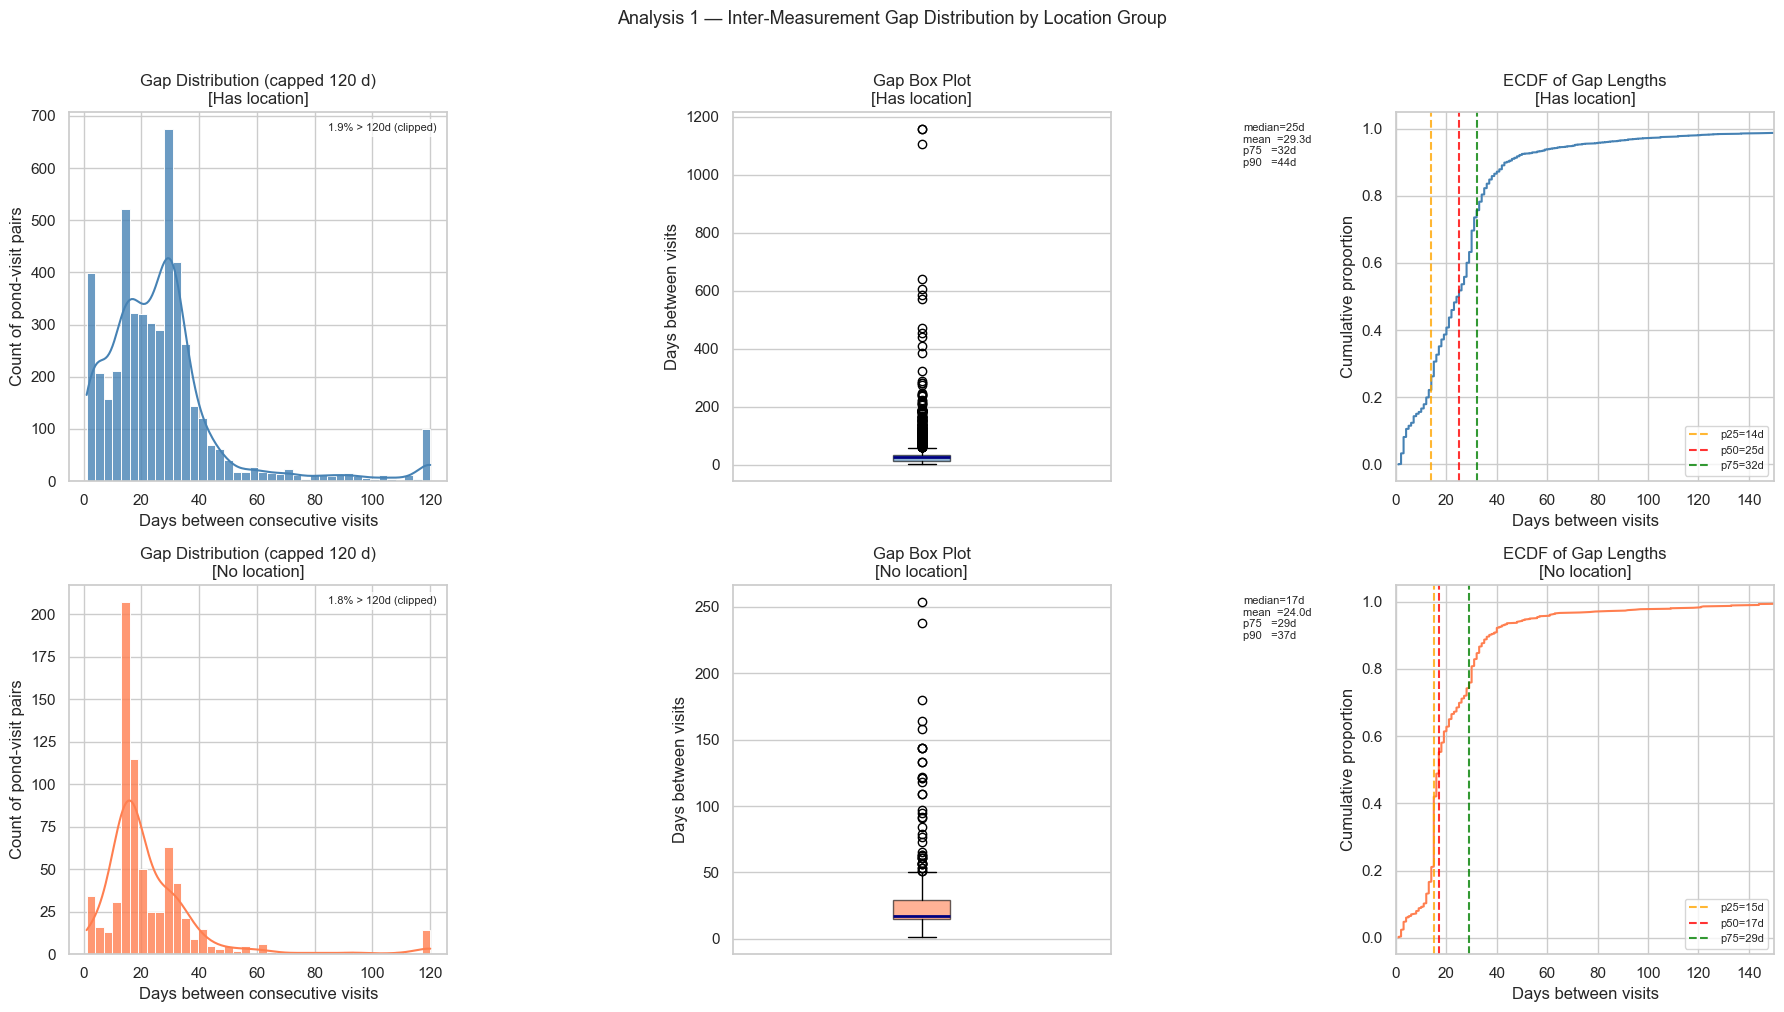

In [14]:
groups = ['Has location', 'No location']
cap = 120

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row_i, grp in enumerate(groups):
    g = gaps[gaps['location_group'] == grp]
    color = LOC_PALETTE[grp]

    # Histogram
    ax = axes[row_i, 0]
    data_plot = g['gap_days'].clip(upper=cap)
    sns.histplot(data_plot, bins=40, kde=True, color=color, ax=ax, alpha=0.8)
    ax.set_title(f'Gap Distribution (capped {cap} d)\n[{grp}]')
    ax.set_xlabel('Days between consecutive visits')
    ax.set_ylabel('Count of pond-visit pairs')
    pct = (g['gap_days'] > cap).mean() * 100
    ax.text(0.97, 0.97, f'{pct:.1f}% > {cap}d (clipped)',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    # Box plot
    ax = axes[row_i, 1]
    ax.boxplot(g['gap_days'], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(f'Gap Box Plot\n[{grp}]')
    ax.set_ylabel('Days between visits')
    ax.set_xticks([])
    stats_txt = (f"median={g['gap_days'].median():.0f}d\n"
                 f"mean  ={g['gap_days'].mean():.1f}d\n"
                 f"p75   ={g['gap_days'].quantile(0.75):.0f}d\n"
                 f"p90   ={g['gap_days'].quantile(0.90):.0f}d")
    ax.text(1.35, 0.97, stats_txt, transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    # ECDF
    ax = axes[row_i, 2]
    sorted_g = np.sort(g['gap_days'])
    ecdf_y   = np.arange(1, len(sorted_g) + 1) / len(sorted_g)
    ax.plot(sorted_g, ecdf_y, color=color)
    ax.set_xlim(0, 150)
    for p, c in [(0.25, 'orange'), (0.50, 'red'), (0.75, 'green')]:
        v = np.percentile(sorted_g, p * 100)
        ax.axvline(v, color=c, linestyle='--', alpha=0.8,
                   label=f'p{int(p*100)}={v:.0f}d')
    ax.legend(fontsize=8)
    ax.set_title(f'ECDF of Gap Lengths\n[{grp}]')
    ax.set_xlabel('Days between visits')
    ax.set_ylabel('Cumulative proportion')

plt.suptitle('Analysis 1 — Inter-Measurement Gap Distribution by Location Group',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Analysis 2 — Gap Interval Categories

Cadence-band breakdown shown in two side-by-side sets of panels (one per location group).

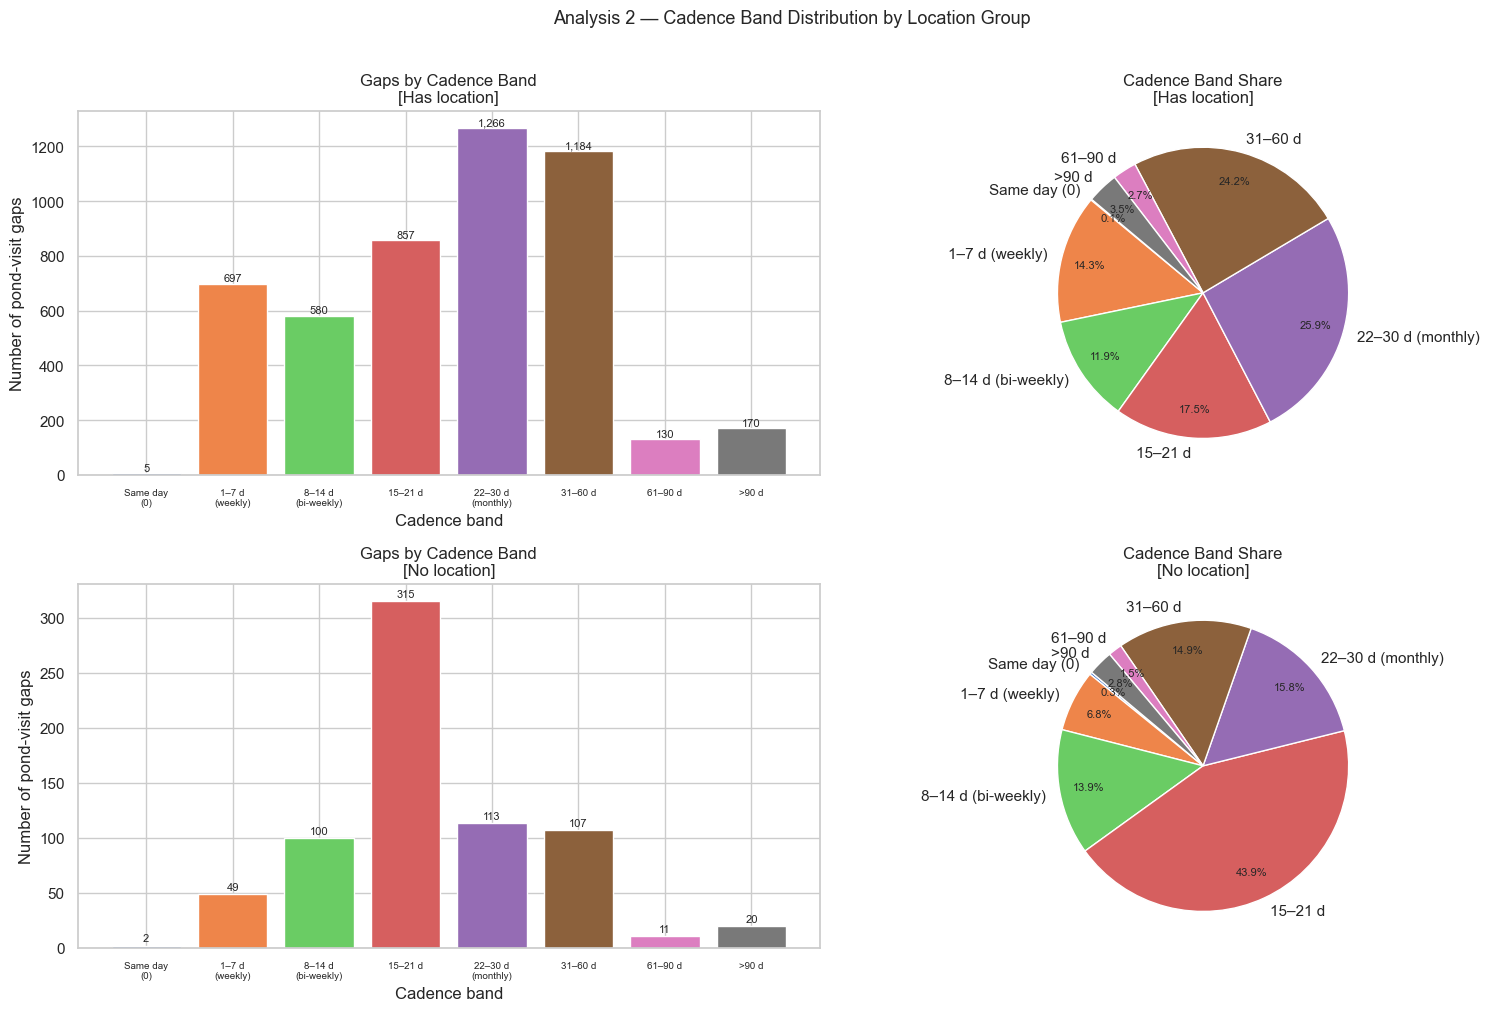

In [15]:
bins   = [0, 1, 7, 14, 21, 30, 60, 90, float('inf')]
labels = ['Same day\n(0)', '1–7 d\n(weekly)', '8–14 d\n(bi-weekly)',
          '15–21 d', '22–30 d\n(monthly)', '31–60 d', '61–90 d', '>90 d']

gaps_cat = gaps.copy()
gaps_cat['gap_cat'] = pd.cut(gaps_cat['gap_days'], bins=bins, labels=labels, right=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row_i, grp in enumerate(groups):
    g = gaps_cat[gaps_cat['location_group'] == grp]
    cat_counts = g['gap_cat'].value_counts().reindex(labels)
    colors = sns.color_palette('muted', n_colors=len(labels))

    # Bar chart
    ax = axes[row_i, 0]
    bars = ax.bar(labels, cat_counts.values, color=colors, edgecolor='white')
    ax.set_title(f'Gaps by Cadence Band\n[{grp}]')
    ax.set_xlabel('Cadence band')
    ax.set_ylabel('Number of pond-visit gaps')
    for bar, v in zip(bars, cat_counts.values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f'{int(v):,}', ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)

    # Pie chart
    ax = axes[row_i, 1]
    valid = cat_counts.dropna()
    wedges, texts, autotexts = ax.pie(
        valid,
        labels=[l.replace('\n', ' ') for l in valid.index],
        autopct='%1.1f%%',
        colors=colors[:len(valid)],
        startangle=140,
        pctdistance=0.8,
    )
    for t in autotexts:
        t.set_fontsize(8)
    ax.set_title(f'Cadence Band Share\n[{grp}]')

plt.suptitle('Analysis 2 — Cadence Band Distribution by Location Group', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Analysis 3 — Total Observations per Pond

The observation-count histogram and ECDF use `hue` to overlay both groups. The top-20 bar chart is shown separately for each group.

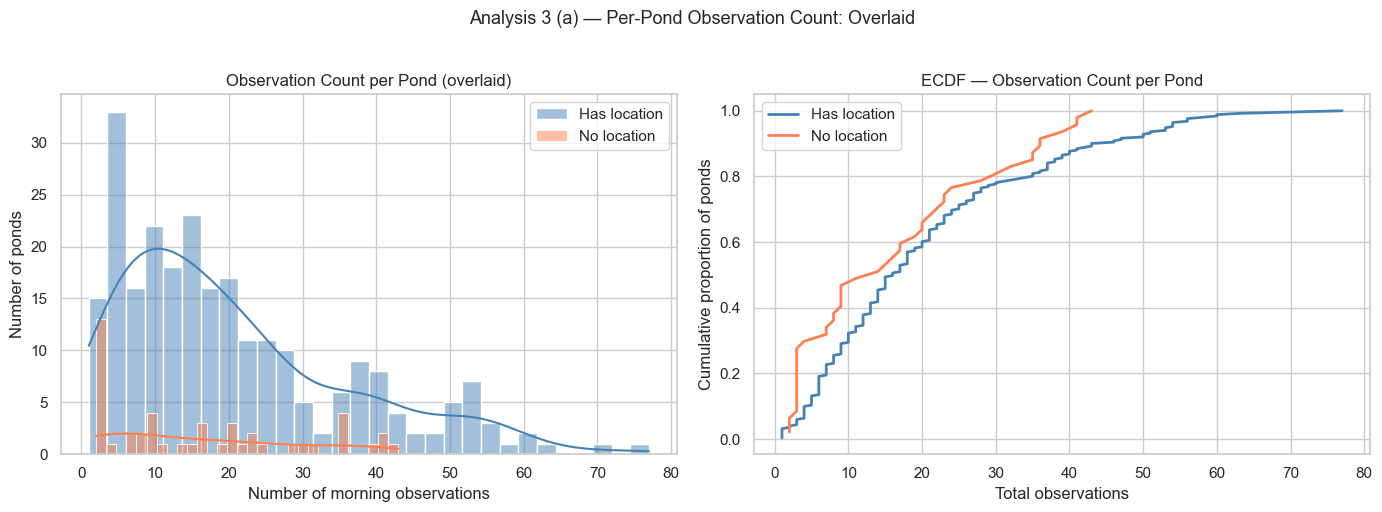

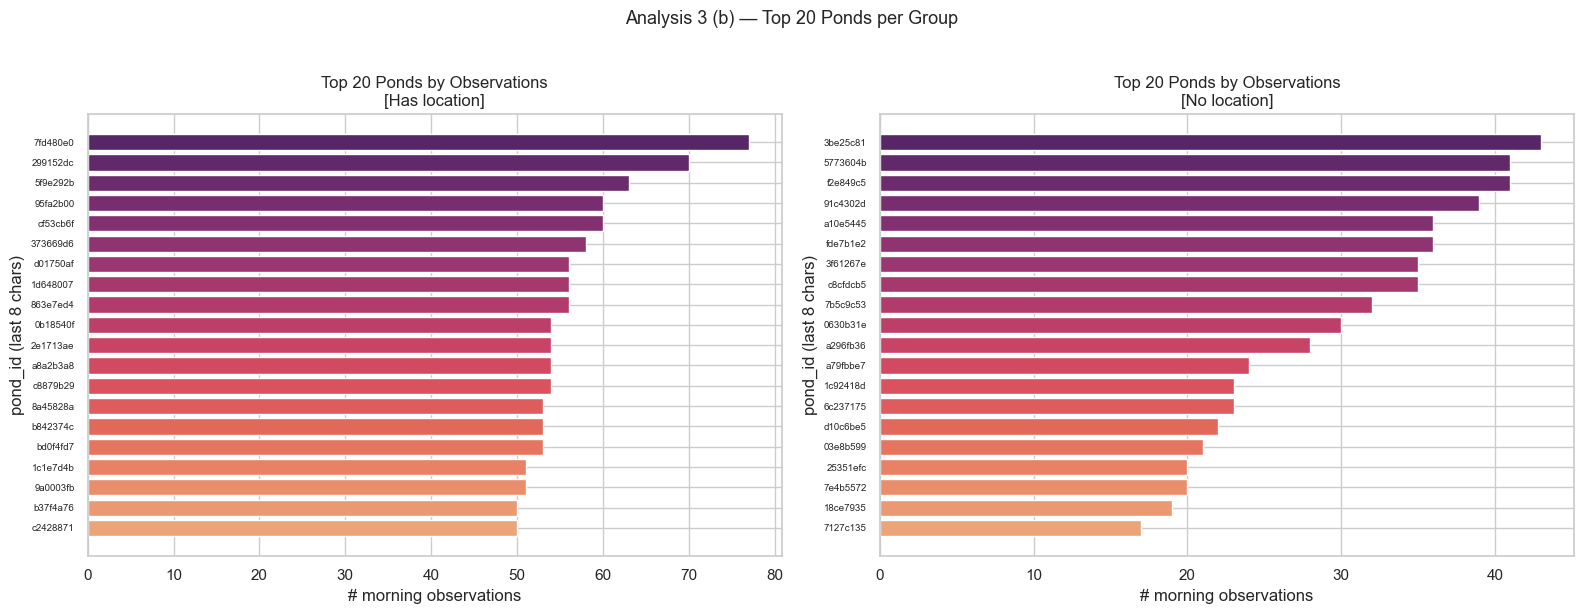

[Has location]  ponds ≥30 obs: 57 (22.7%)  | ponds ≤5 obs: 33 (13.1%)
[No location]  ponds ≥30 obs: 10 (21.3%)  | ponds ≤5 obs: 14 (29.8%)


In [16]:
# ── Overlaid histogram + ECDF (same chart, hue by group) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for grp in groups:
    sub = pond_summary[pond_summary['location_group'] == grp]
    color = LOC_PALETTE[grp]
    sns.histplot(sub['n_obs'], bins=30, kde=True, color=color, label=grp,
                 alpha=0.5, ax=ax)
ax.legend()
ax.set_title('Observation Count per Pond (overlaid)')
ax.set_xlabel('Number of morning observations')
ax.set_ylabel('Number of ponds')

ax = axes[1]
for grp in groups:
    sub = pond_summary[pond_summary['location_group'] == grp]
    sorted_n = np.sort(sub['n_obs'])
    ecdf_y   = np.arange(1, len(sorted_n)+1) / len(sorted_n)
    ax.plot(sorted_n, ecdf_y, color=LOC_PALETTE[grp], label=grp, linewidth=2)
ax.legend()
ax.set_title('ECDF — Observation Count per Pond')
ax.set_xlabel('Total observations')
ax.set_ylabel('Cumulative proportion of ponds')

plt.suptitle('Analysis 3 (a) — Per-Pond Observation Count: Overlaid', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Top 20 ponds per group (separate side-by-side) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, grp in zip(axes, groups):
    sub = pond_summary[pond_summary['location_group'] == grp]
    top20 = sub.nlargest(20, 'n_obs').sort_values('n_obs')
    short_id = top20['pond_id'].str[-8:]
    colors_bar = sns.color_palette('flare', n_colors=len(top20))
    ax.barh(short_id, top20['n_obs'], color=colors_bar)
    ax.set_title(f'Top 20 Ponds by Observations\n[{grp}]')
    ax.set_xlabel('# morning observations')
    ax.set_ylabel('pond_id (last 8 chars)')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Analysis 3 (b) — Top 20 Ponds per Group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

for grp in groups:
    sub = pond_summary[pond_summary['location_group'] == grp]
    print(f"[{grp}]  ponds ≥30 obs: {(sub['n_obs']>=30).sum()} "
          f"({(sub['n_obs']>=30).mean()*100:.1f}%)  "
          f"| ponds ≤5 obs: {(sub['n_obs']<=5).sum()} "
          f"({(sub['n_obs']<=5).mean()*100:.1f}%)")

## Analysis 4 — Ponds Measured per Day (Time Series)

Two separate time-series rows: `Has location` on top, `No location` below, each with a daily count and 30-day rolling mean.

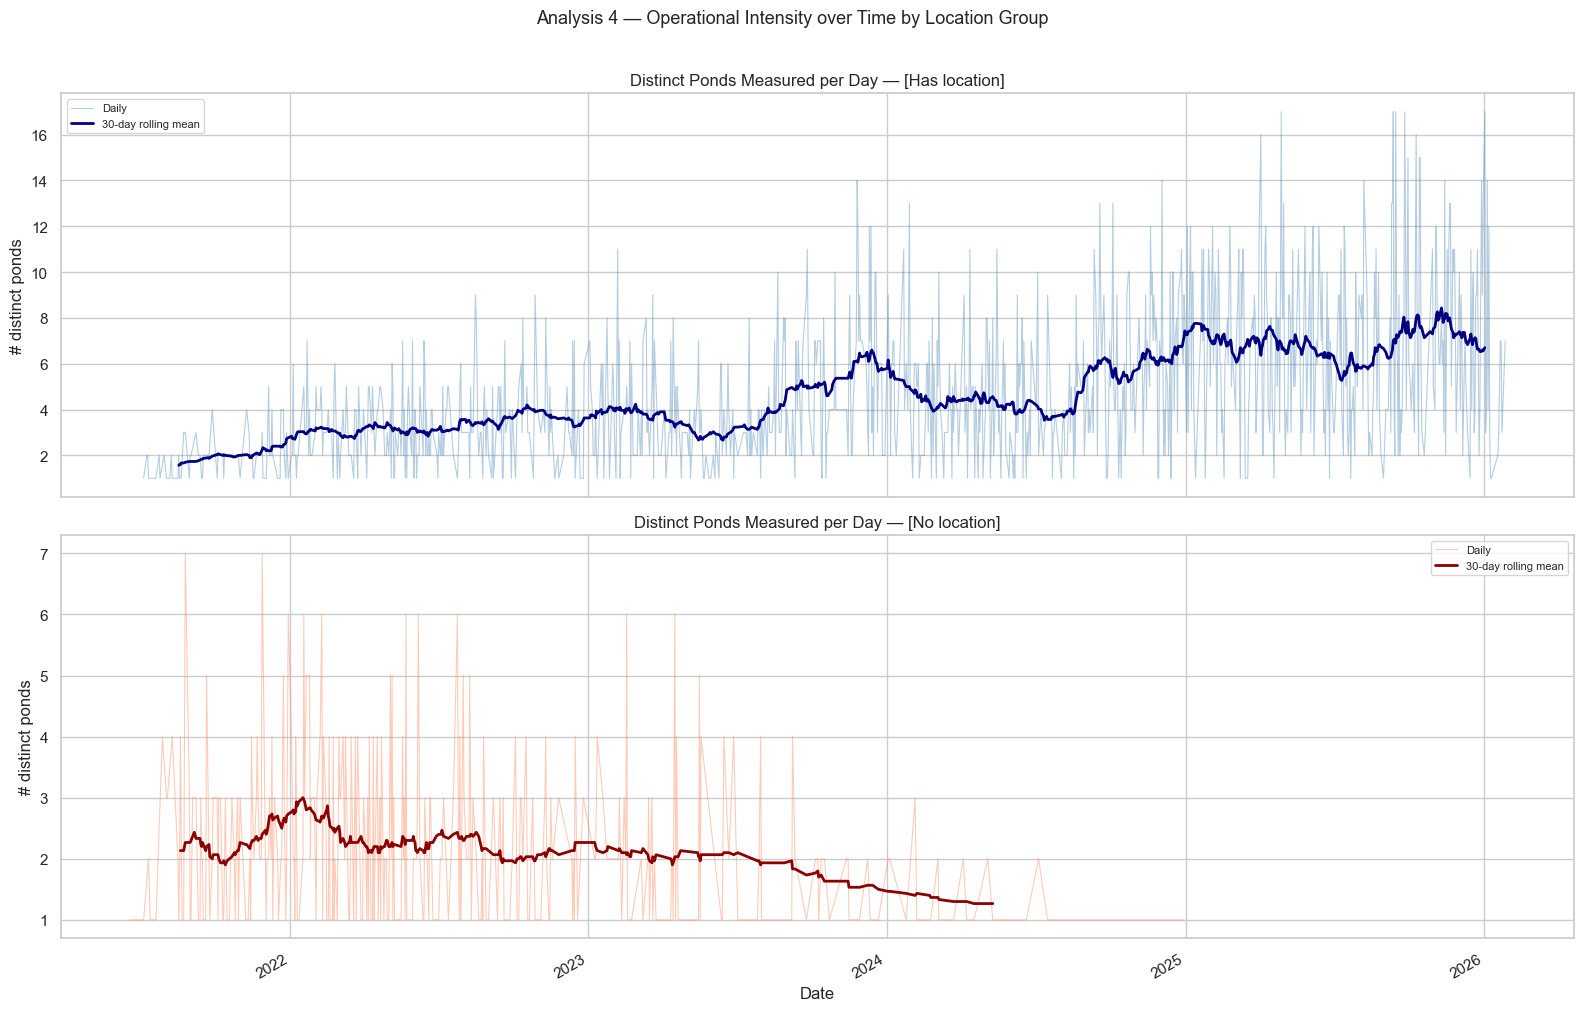

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, grp in zip(axes, groups):
    m_grp = morning[morning['location_group'] == grp]
    daily = m_grp.groupby('date')['pond_id'].nunique().rename('n_ponds').sort_index()
    color = LOC_PALETTE[grp]
    daily.plot(ax=ax, color=color, alpha=0.4, linewidth=0.8, label='Daily')
    daily.rolling(30, center=True).mean().plot(
        ax=ax, color='navy' if grp == 'Has location' else 'darkred',
        linewidth=2, label='30-day rolling mean')
    ax.set_title(f'Distinct Ponds Measured per Day — [{grp}]')
    ax.set_ylabel('# distinct ponds')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Date')
plt.suptitle('Analysis 4 — Operational Intensity over Time by Location Group',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Analysis 5 — Monthly Observation Counts and Unique Ponds

Two figures stacked: total monthly observations and unique ponds per month, each showing both groups in the same bar chart using side-by-side bars.

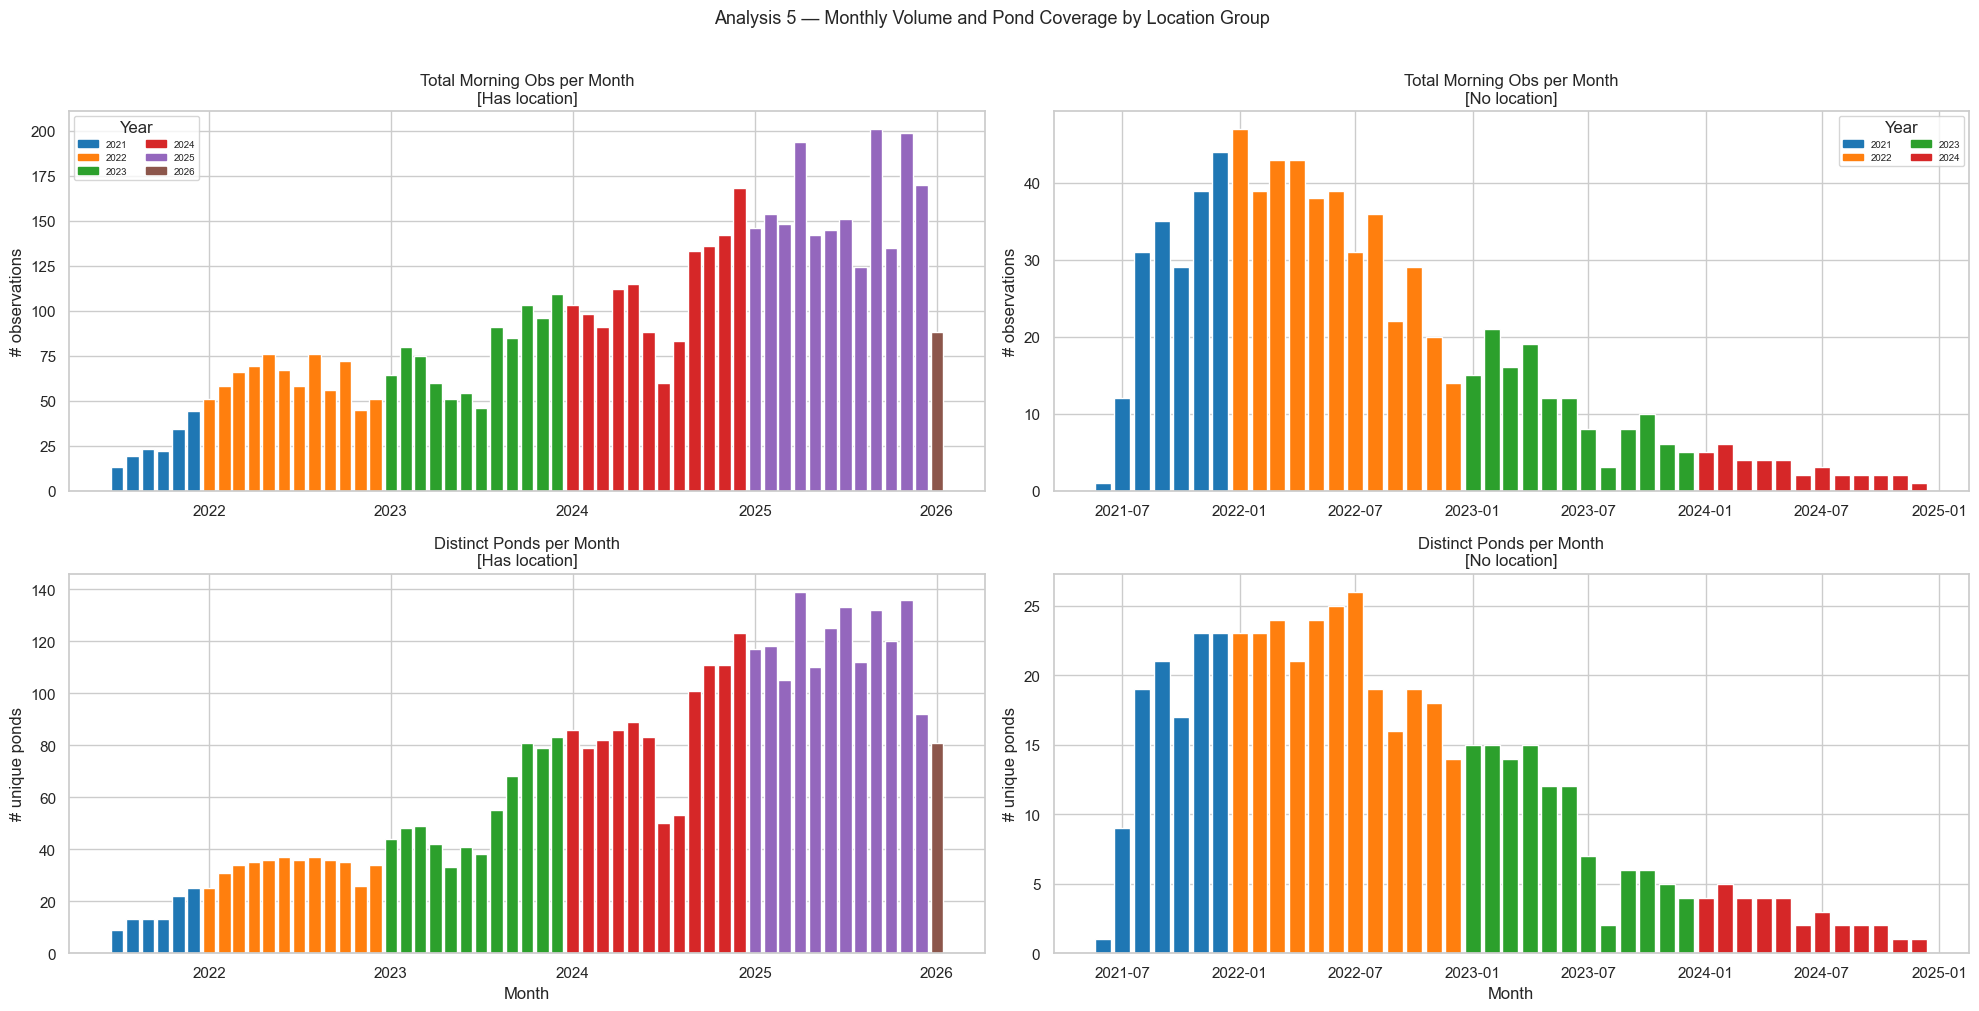

In [18]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

for col_i, grp in enumerate(groups):
    m_grp = morning[morning['location_group'] == grp]
    color = LOC_PALETTE[grp]

    monthly = m_grp.groupby('month').agg(
        total_obs=('pond_id', 'count'),
        unique_ponds=('pond_id', 'nunique'),
    ).reset_index()
    monthly['month_dt'] = monthly['month'].dt.to_timestamp()
    monthly['year'] = monthly['month_dt'].dt.year
    palette = {y: c for y, c in zip(sorted(monthly['year'].unique()),
               sns.color_palette('tab10', n_colors=monthly['year'].nunique()))}
    bar_colors = [palette[y] for y in monthly['year']]

    ax = axes[0, col_i]
    ax.bar(monthly['month_dt'], monthly['total_obs'], width=25, color=bar_colors)
    ax.set_title(f'Total Morning Obs per Month\n[{grp}]')
    ax.set_ylabel('# observations')
    legend_handles = [Patch(color=c, label=str(y)) for y, c in palette.items()]
    ax.legend(handles=legend_handles, title='Year', fontsize=7, ncol=2)

    ax = axes[1, col_i]
    ax.bar(monthly['month_dt'], monthly['unique_ponds'], width=25, color=bar_colors)
    ax.set_title(f'Distinct Ponds per Month\n[{grp}]')
    ax.set_ylabel('# unique ponds')
    ax.set_xlabel('Month')

plt.suptitle('Analysis 5 — Monthly Volume and Pond Coverage by Location Group',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Analysis 6 — Quarterly Trends

Three-panel quarterly breakdown (total obs, unique ponds, mean gap) shown separately for each group.

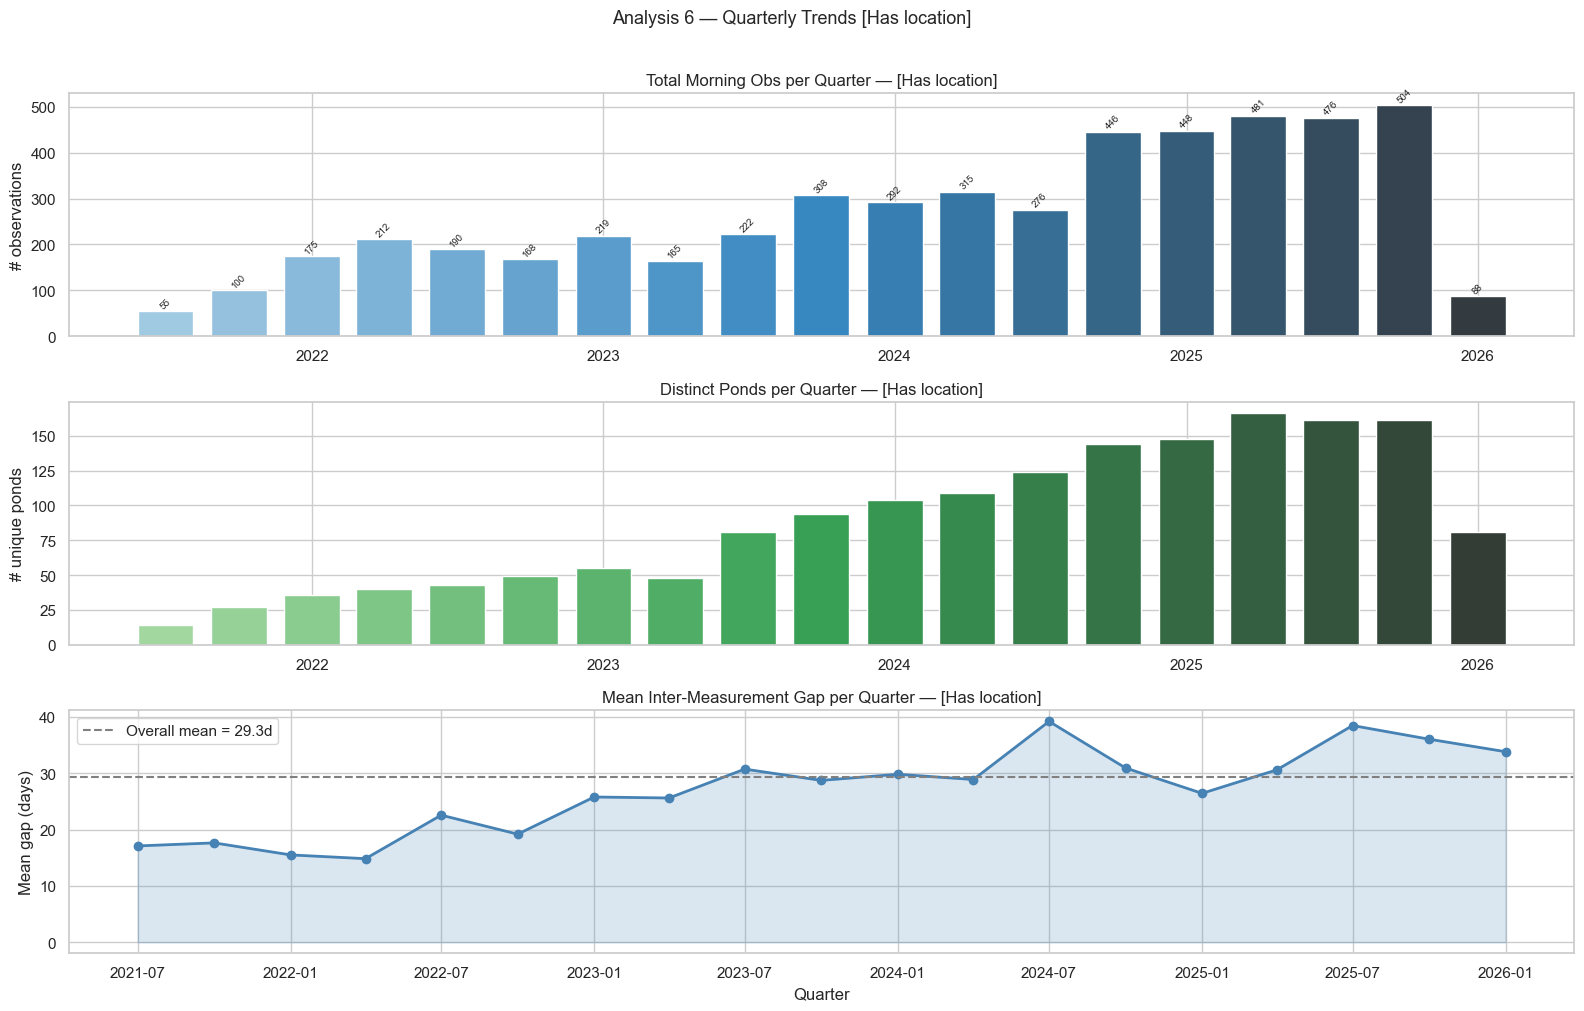

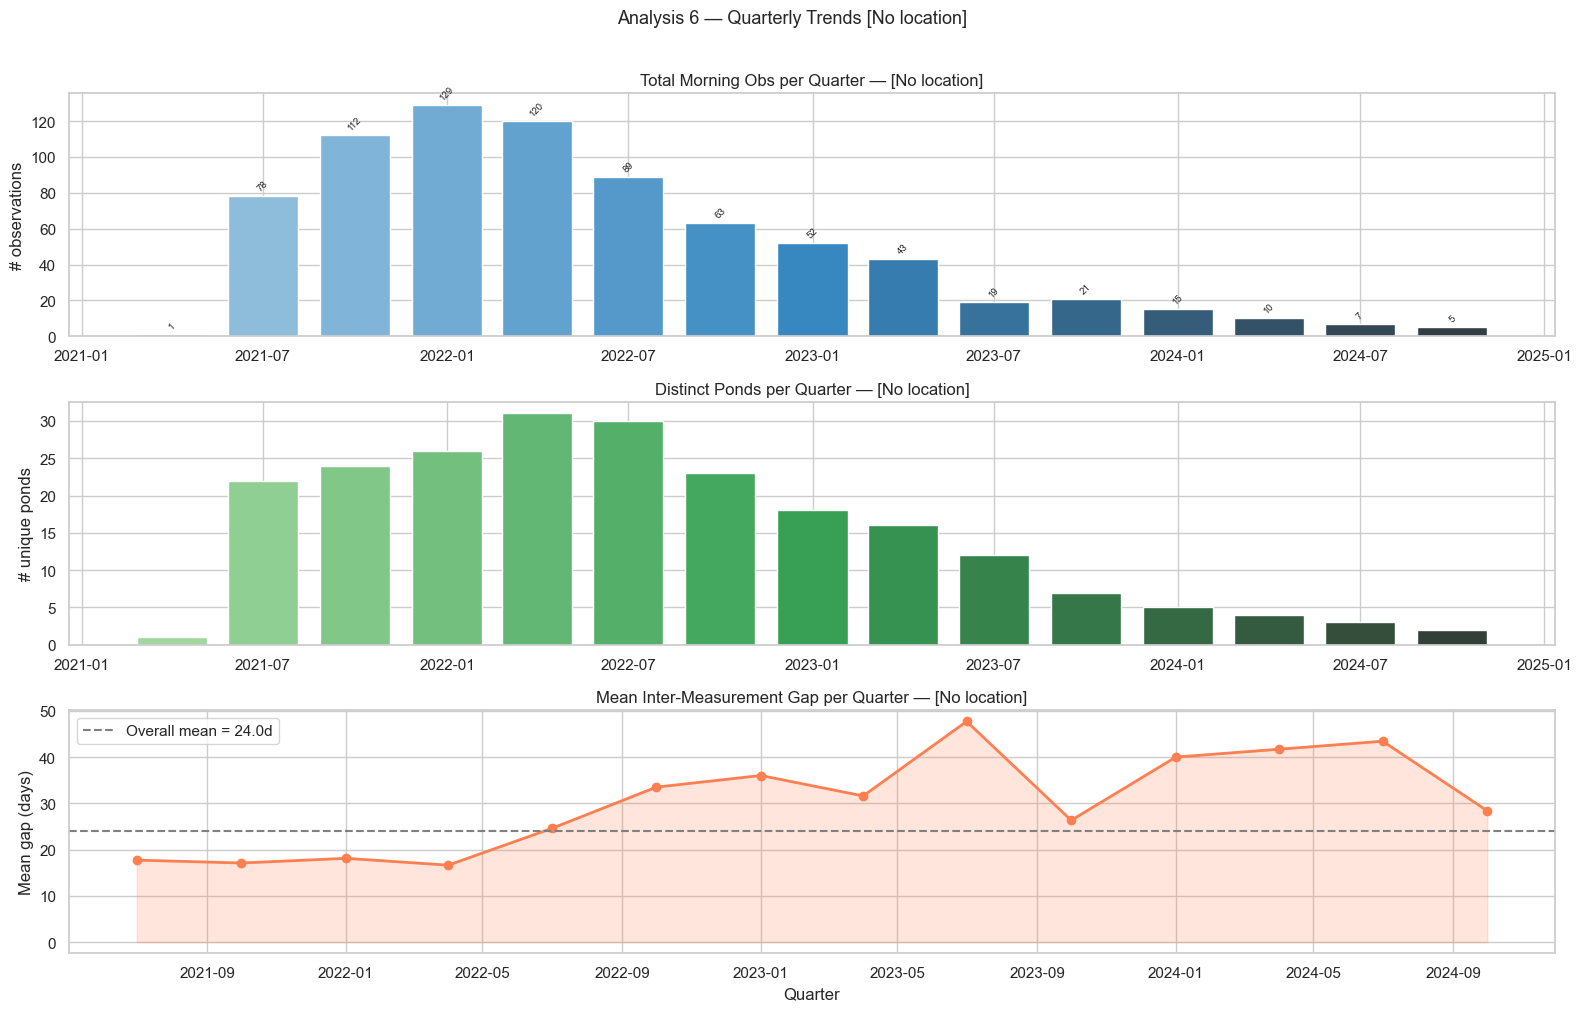

In [19]:
for grp in groups:
    m_grp  = morning[morning['location_group'] == grp]
    g_grp  = gaps[gaps['location_group'] == grp]
    color  = LOC_PALETTE[grp]

    quarterly = m_grp.groupby('quarter').agg(
        total_obs=('pond_id', 'count'),
        unique_ponds=('pond_id', 'nunique'),
    ).reset_index()
    quarterly['q_dt'] = quarterly['quarter'].dt.to_timestamp()

    q_gap_mean = g_grp.copy()
    q_gap_mean['quarter'] = q_gap_mean['date'].dt.to_period('Q')
    q_gap_mean = q_gap_mean.groupby('quarter')['gap_days'].mean().reset_index()
    q_gap_mean['q_dt'] = q_gap_mean['quarter'].dt.to_timestamp()

    fig, axes = plt.subplots(3, 1, figsize=(16, 10))

    ax = axes[0]
    ax.bar(quarterly['q_dt'], quarterly['total_obs'], width=70,
           color=sns.color_palette('Blues_d', n_colors=len(quarterly)))
    ax.set_title(f'Total Morning Obs per Quarter — [{grp}]')
    ax.set_ylabel('# observations')
    for _, row in quarterly.iterrows():
        ax.text(row['q_dt'], row['total_obs'] + 2, str(int(row['total_obs'])),
                ha='center', va='bottom', fontsize=7, rotation=45)

    ax = axes[1]
    ax.bar(quarterly['q_dt'], quarterly['unique_ponds'], width=70,
           color=sns.color_palette('Greens_d', n_colors=len(quarterly)))
    ax.set_title(f'Distinct Ponds per Quarter — [{grp}]')
    ax.set_ylabel('# unique ponds')

    ax = axes[2]
    ax.plot(q_gap_mean['q_dt'], q_gap_mean['gap_days'], marker='o',
            color=color, linewidth=2)
    ax.fill_between(q_gap_mean['q_dt'], q_gap_mean['gap_days'], alpha=0.2, color=color)
    ax.axhline(g_grp['gap_days'].mean(), color='grey', linestyle='--',
               label=f"Overall mean = {g_grp['gap_days'].mean():.1f}d")
    ax.set_title(f'Mean Inter-Measurement Gap per Quarter — [{grp}]')
    ax.set_ylabel('Mean gap (days)')
    ax.set_xlabel('Quarter')
    ax.legend()

    plt.suptitle(f'Analysis 6 — Quarterly Trends [{grp}]', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## Analysis 7 — Measurement Presence Heatmap (Ponds × Months)

Top 50 ponds (by observation count) shown separately for each location group. Each cell = morning visits in that month.

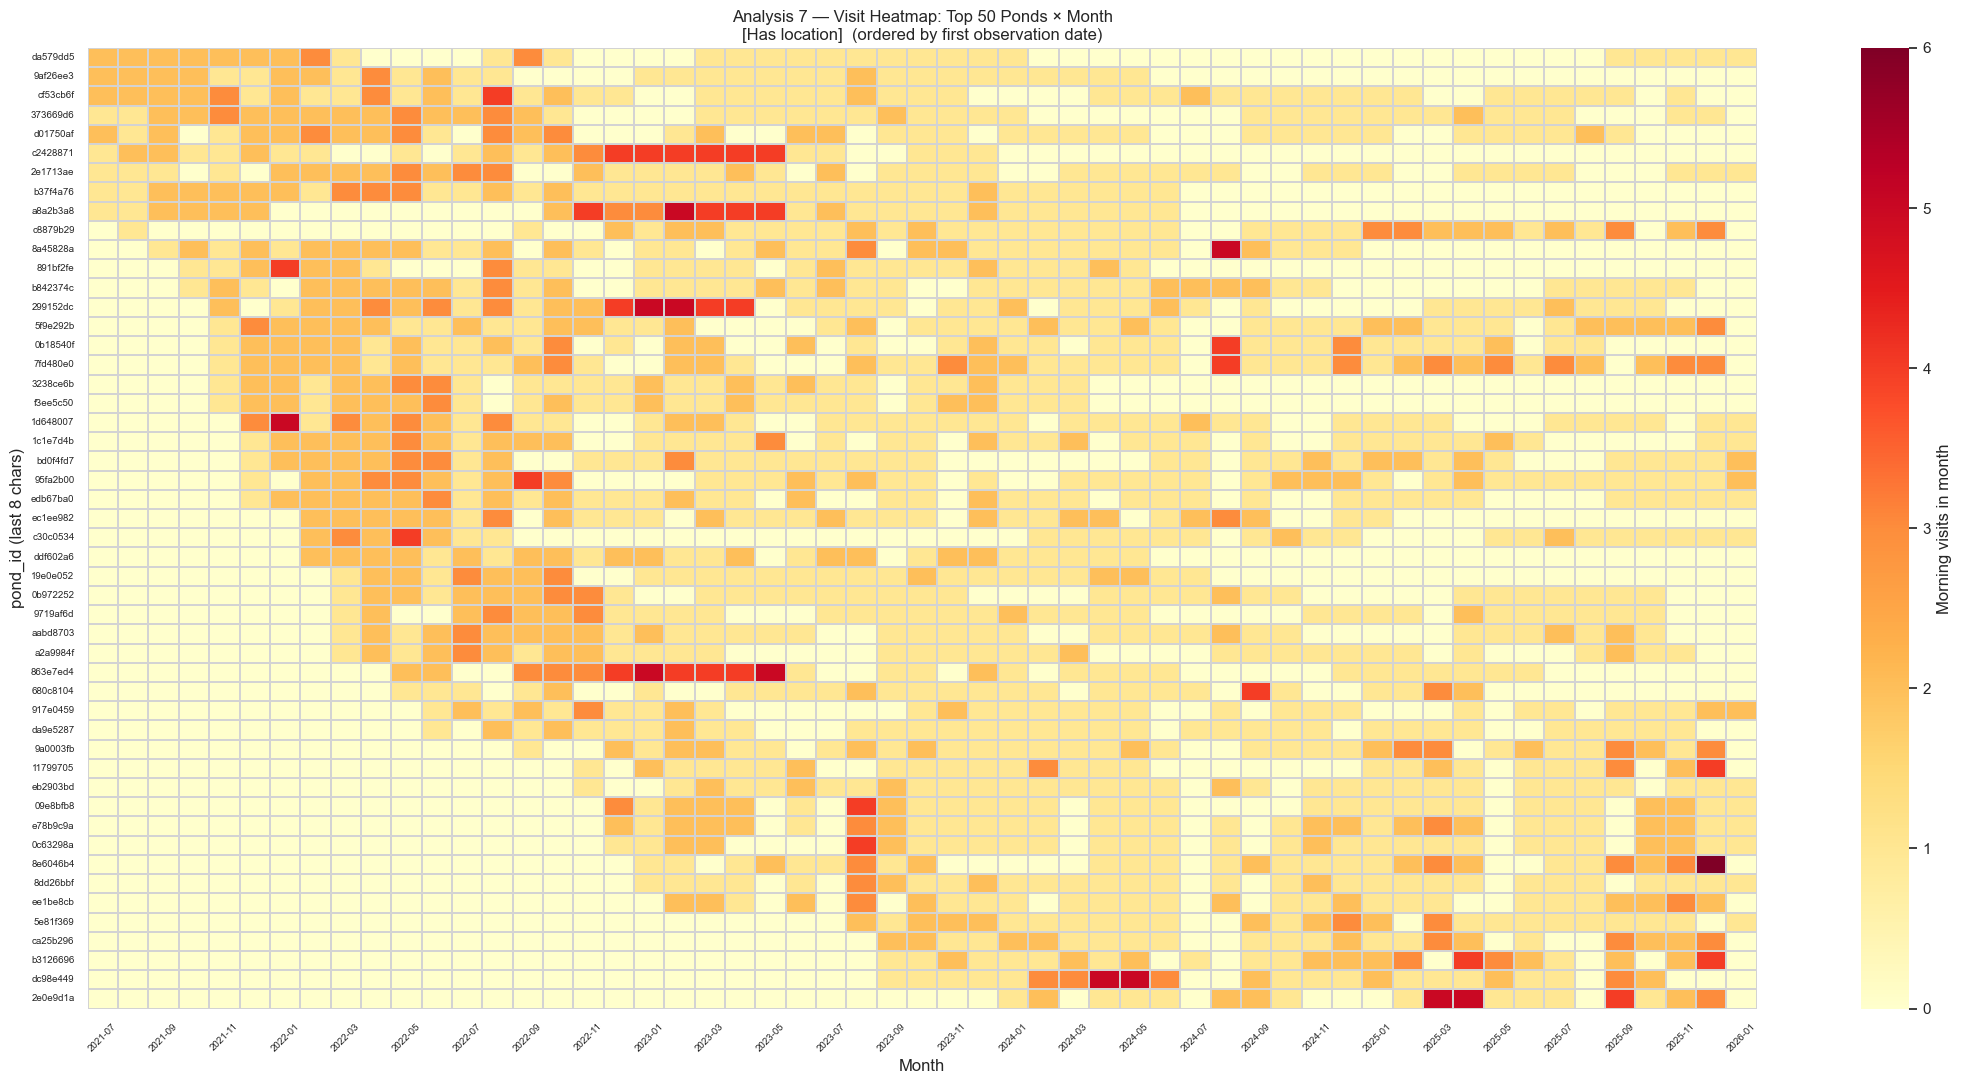

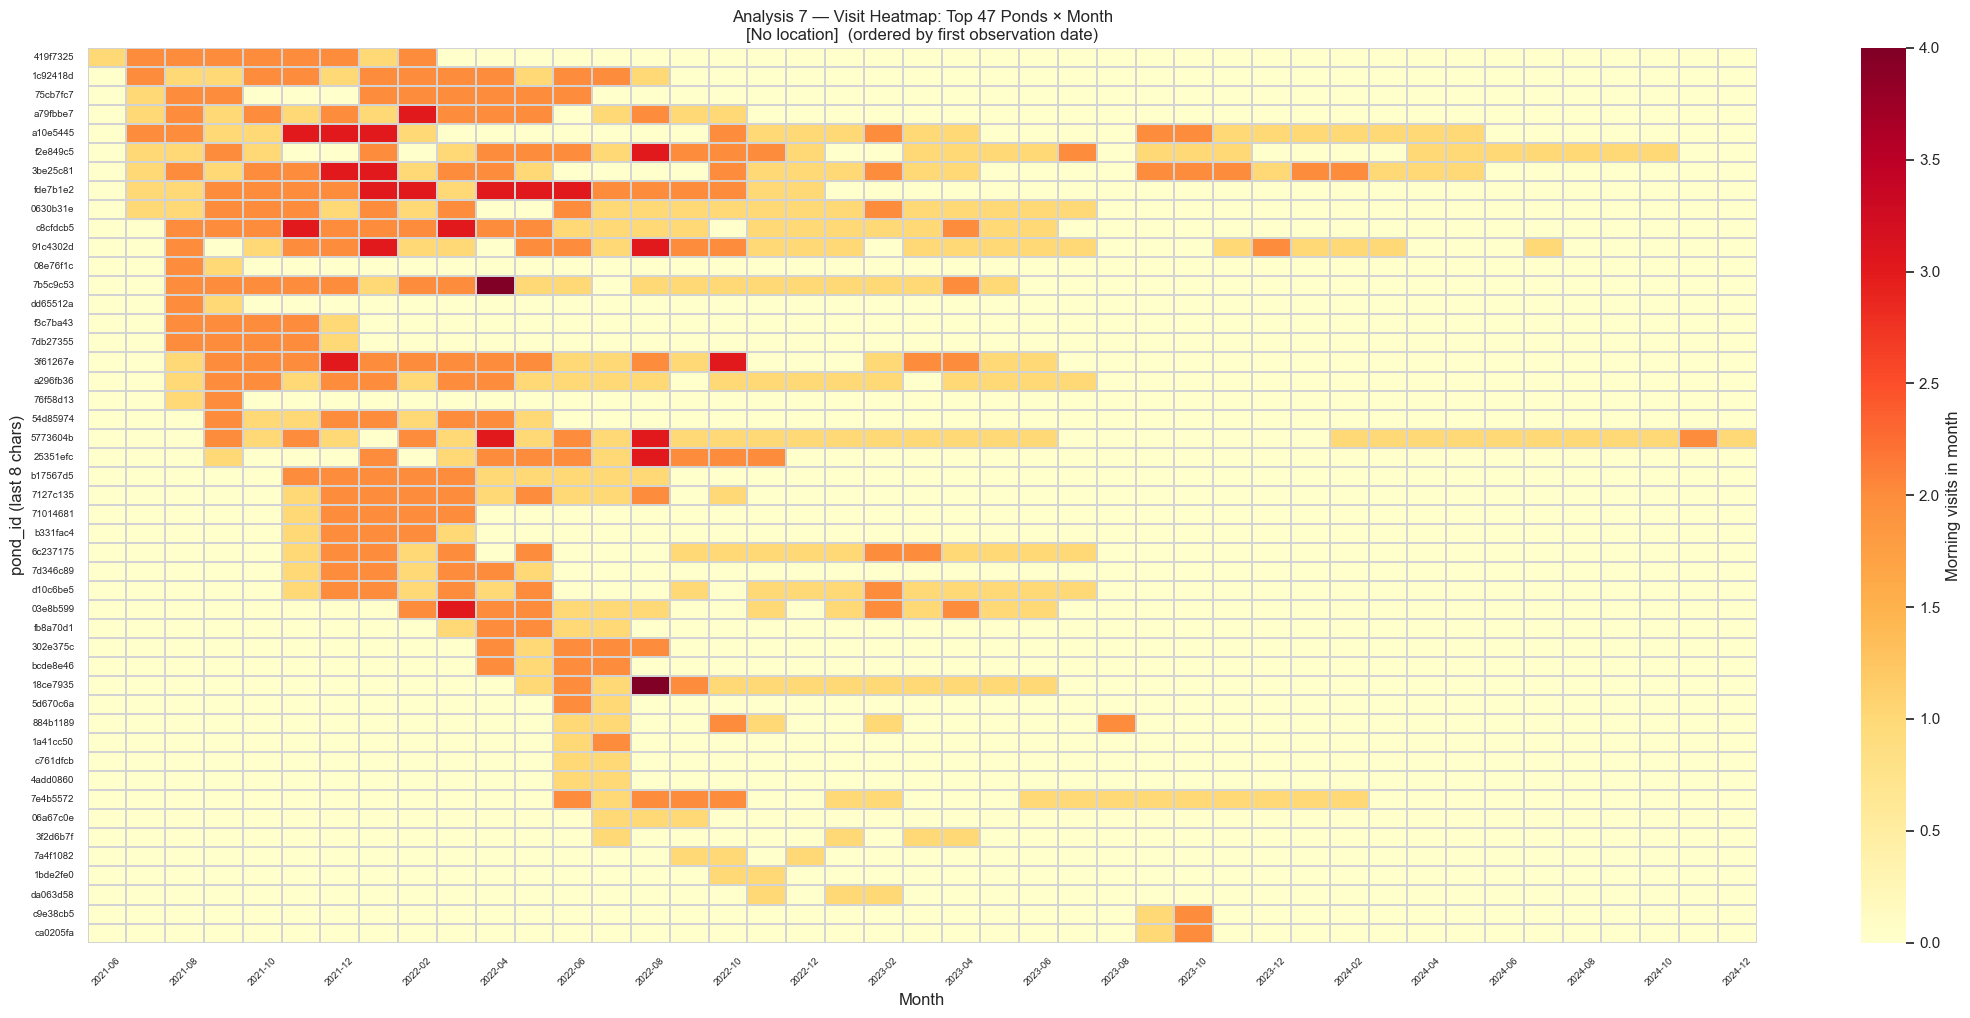

In [20]:
TOP_N = 50

for grp in groups:
    m_grp = morning[morning['location_group'] == grp]
    ps_grp = pond_summary[pond_summary['location_group'] == grp]

    top_ponds = ps_grp.nlargest(min(TOP_N, len(ps_grp)), 'n_obs')['pond_id'].tolist()
    if not top_ponds:
        print(f"[{grp}] — no ponds to plot")
        continue

    heat_df = (m_grp[m_grp['pond_id'].isin(top_ponds)]
               .groupby(['pond_id', 'month'])
               .size()
               .unstack(fill_value=0))

    first_obs_order = ps_grp.set_index('pond_id').loc[
        [p for p in top_ponds if p in ps_grp.set_index('pond_id').index],
        'first_date'].sort_values().index
    heat_df = heat_df.reindex([p for p in first_obs_order if p in heat_df.index])
    heat_df.index = [idx[-8:] for idx in heat_df.index]
    heat_df.columns = heat_df.columns.astype(str)
    heat_df = heat_df.loc[:, (heat_df > 0).any()]

    row_h = max(6, len(heat_df) * 0.22)
    fig, ax = plt.subplots(figsize=(22, row_h))
    sns.heatmap(heat_df, cmap='YlOrRd', linewidths=0.3, linecolor='lightgrey',
                cbar_kws={'label': 'Morning visits in month'},
                xticklabels=2, ax=ax)
    ax.set_title(f'Analysis 7 — Visit Heatmap: Top {len(top_ponds)} Ponds × Month\n'
                 f'[{grp}]  (ordered by first observation date)', fontsize=12)
    ax.set_xlabel('Month')
    ax.set_ylabel('pond_id (last 8 chars)')
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout()
    plt.show()

## Analysis 8 — Regularity: Distribution of CV Across Ponds

CV histogram uses `hue` (overlaid) for easy comparison. The strip chart (most vs least regular) and tier bar chart are shown separately per group.

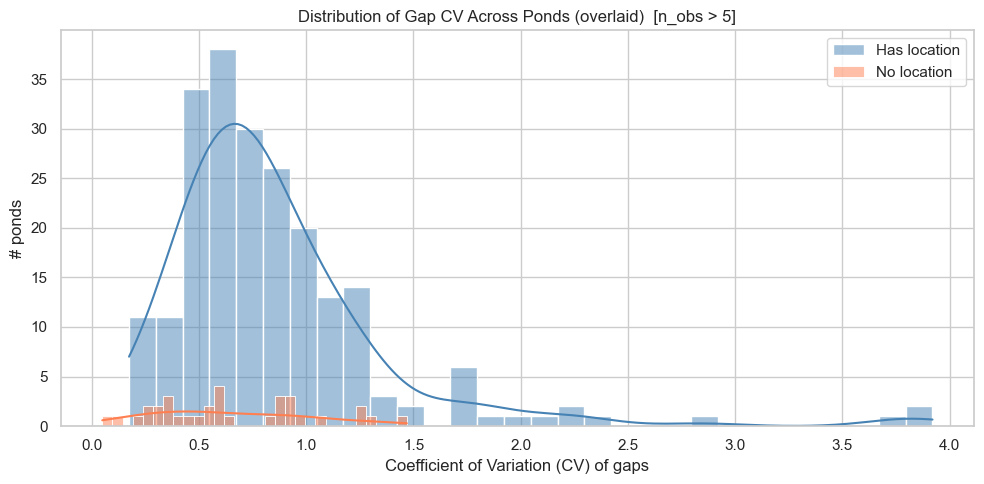

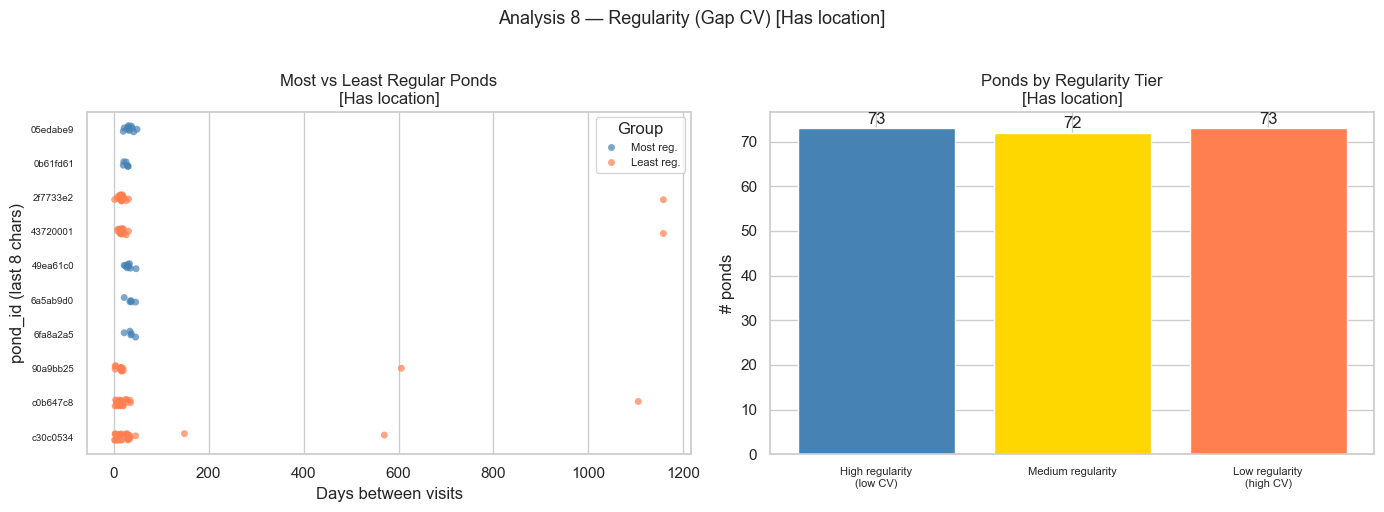

[Has location]  n_ponds=218  median CV=0.73  mean CV=0.86


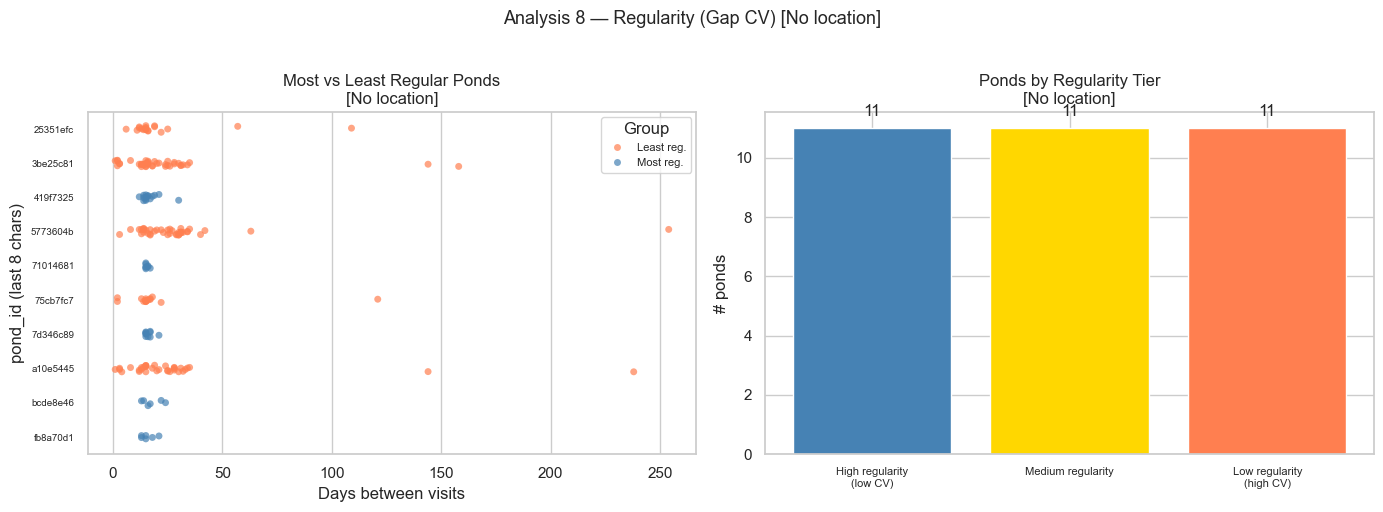

[No location]  n_ponds=33  median CV=0.59  mean CV=0.65


In [21]:
MIN_GAPS = 5
reg_all = pond_summary.dropna(subset=['cv_gap'])
reg_all = reg_all[reg_all['n_obs'] > MIN_GAPS].copy()

# ── Overlaid CV histogram ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for grp in groups:
    sub = reg_all[reg_all['location_group'] == grp]
    sns.histplot(sub['cv_gap'], bins=30, kde=True, label=grp,
                 color=LOC_PALETTE[grp], alpha=0.5, ax=ax)
ax.legend()
ax.set_title(f'Distribution of Gap CV Across Ponds (overlaid)  [n_obs > {MIN_GAPS}]')
ax.set_xlabel('Coefficient of Variation (CV) of gaps')
ax.set_ylabel('# ponds')
plt.tight_layout()
plt.show()

# ── Per-group: strip plots + tier bars ───────────────────────────────────────
for grp in groups:
    reg_df = reg_all[reg_all['location_group'] == grp].copy()
    if len(reg_df) < 3:
        print(f"[{grp}] — insufficient data for regularity analysis")
        continue

    q33, q67 = reg_df['cv_gap'].quantile([1/3, 2/3]).values
    reg_df['regularity_tier'] = pd.cut(
        reg_df['cv_gap'],
        bins=[-np.inf, q33, q67, np.inf],
        labels=['High regularity\n(low CV)', 'Medium regularity', 'Low regularity\n(high CV)']
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Strip plot — most vs least regular
    ax = axes[0]
    n_show = min(5, len(reg_df) // 2)
    most_reg  = reg_df.nsmallest(n_show, 'cv_gap')['pond_id'].tolist()
    least_reg = reg_df.nlargest(n_show,  'cv_gap')['pond_id'].tolist()
    focus_ids = most_reg + least_reg
    focus_gaps = gaps[(gaps['pond_id'].isin(focus_ids)) &
                      (gaps['location_group'] == grp)].copy()
    focus_gaps['tag']      = focus_gaps['pond_id'].map(
        {p: ('Most reg.' if p in most_reg else 'Least reg.') for p in focus_ids})
    focus_gaps['short_id'] = focus_gaps['pond_id'].str[-8:]
    palette_strip = {'Most reg.': 'steelblue', 'Least reg.': 'coral'}
    sns.stripplot(data=focus_gaps, y='short_id', x='gap_days', hue='tag',
                  palette=palette_strip, jitter=True, alpha=0.7, ax=ax)
    ax.set_title(f'Most vs Least Regular Ponds\n[{grp}]')
    ax.set_xlabel('Days between visits')
    ax.set_ylabel('pond_id (last 8 chars)')
    ax.tick_params(axis='y', labelsize=7)
    ax.legend(title='Group', fontsize=8)

    # Tier counts
    ax = axes[1]
    tier_labels = ['High regularity\n(low CV)', 'Medium regularity', 'Low regularity\n(high CV)']
    tier_counts = reg_df['regularity_tier'].value_counts().reindex(tier_labels)
    ax.bar(tier_labels, tier_counts.values, color=['steelblue', 'gold', 'coral'])
    ax.set_title(f'Ponds by Regularity Tier\n[{grp}]')
    ax.set_ylabel('# ponds')
    ax.tick_params(axis='x', labelsize=8)
    for i, v in enumerate(tier_counts.values):
        if not np.isnan(v):
            ax.text(i, v + 0.3, str(int(v)), ha='center', va='bottom')

    plt.suptitle(f'Analysis 8 — Regularity (Gap CV) [{grp}]', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"[{grp}]  n_ponds={len(reg_df)}  "
          f"median CV={reg_df['cv_gap'].median():.2f}  "
          f"mean CV={reg_df['cv_gap'].mean():.2f}")

## Analysis 9 — Regularity vs Measurement Frequency

Separate scatter plots for each group: mean gap vs CV and total observations vs CV.

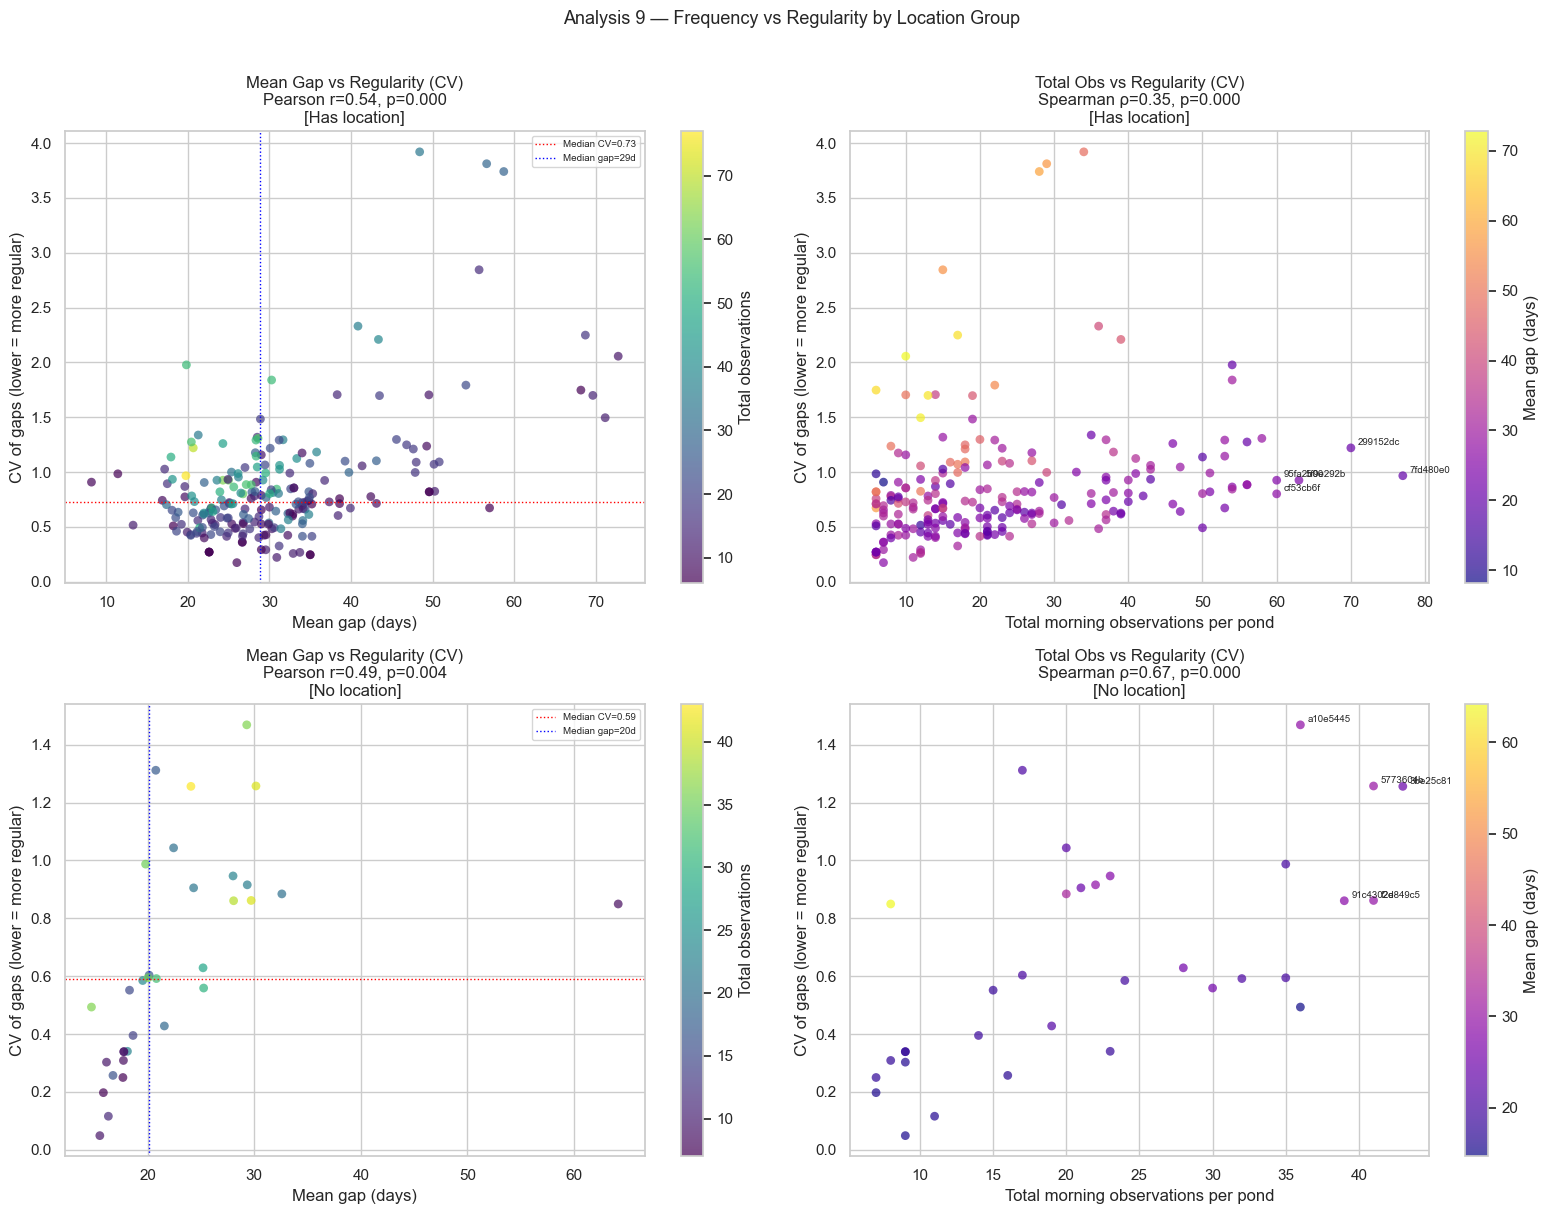

In [22]:
from scipy.stats import pearsonr, spearmanr

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row_i, grp in enumerate(groups):
    reg_df = reg_all[reg_all['location_group'] == grp].copy()
    if len(reg_df) < 3:
        continue

    # Mean gap vs CV
    ax = axes[row_i, 0]
    sc = ax.scatter(reg_df['mean_gap'], reg_df['cv_gap'],
                    c=reg_df['n_obs'], cmap='viridis', alpha=0.7, edgecolors='none', s=40)
    plt.colorbar(sc, ax=ax, label='Total observations')
    r, p = pearsonr(reg_df['mean_gap'].dropna(), reg_df.loc[reg_df['mean_gap'].notna(), 'cv_gap'])
    ax.set_title(f'Mean Gap vs Regularity (CV)\nPearson r={r:.2f}, p={p:.3f}\n[{grp}]')
    ax.set_xlabel('Mean gap (days)')
    ax.set_ylabel('CV of gaps (lower = more regular)')
    ax.axhline(reg_df['cv_gap'].median(), color='red',   linestyle=':', linewidth=1,
               label=f'Median CV={reg_df["cv_gap"].median():.2f}')
    ax.axvline(reg_df['mean_gap'].median(), color='blue', linestyle=':', linewidth=1,
               label=f'Median gap={reg_df["mean_gap"].median():.0f}d')
    ax.legend(fontsize=7)

    # n_obs vs CV
    ax = axes[row_i, 1]
    sc2 = ax.scatter(reg_df['n_obs'], reg_df['cv_gap'],
                     c=reg_df['mean_gap'], cmap='plasma', alpha=0.7, edgecolors='none', s=40)
    plt.colorbar(sc2, ax=ax, label='Mean gap (days)')
    rho, p2 = spearmanr(reg_df['n_obs'], reg_df['cv_gap'])
    ax.set_title(f'Total Obs vs Regularity (CV)\nSpearman ρ={rho:.2f}, p={p2:.3f}\n[{grp}]')
    ax.set_xlabel('Total morning observations per pond')
    ax.set_ylabel('CV of gaps (lower = more regular)')
    for _, row in reg_df.nlargest(5, 'n_obs').iterrows():
        ax.annotate(row['pond_id'][-8:], (row['n_obs'], row['cv_gap']),
                    fontsize=7, xytext=(5, 2), textcoords='offset points')

plt.suptitle('Analysis 9 — Frequency vs Regularity by Location Group', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Analysis 10 — Pond Tenure (Active Span) and Observation Density

Tenure histogram and observation density histogram use `hue` for easy overlay. The tenure vs total-observations scatter is shown separately per group.

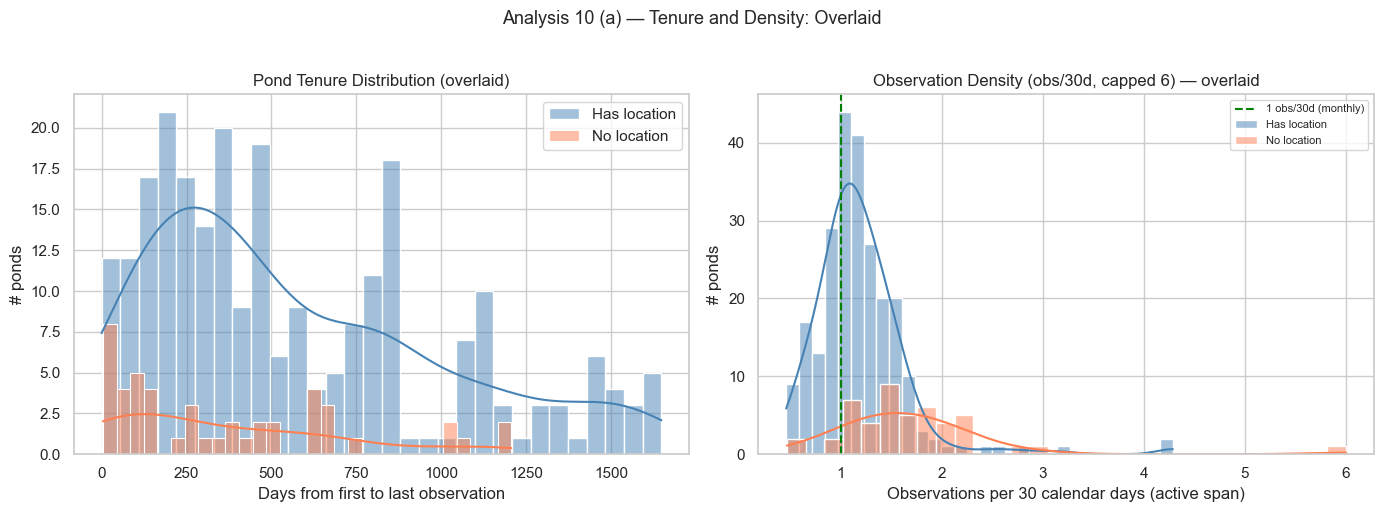

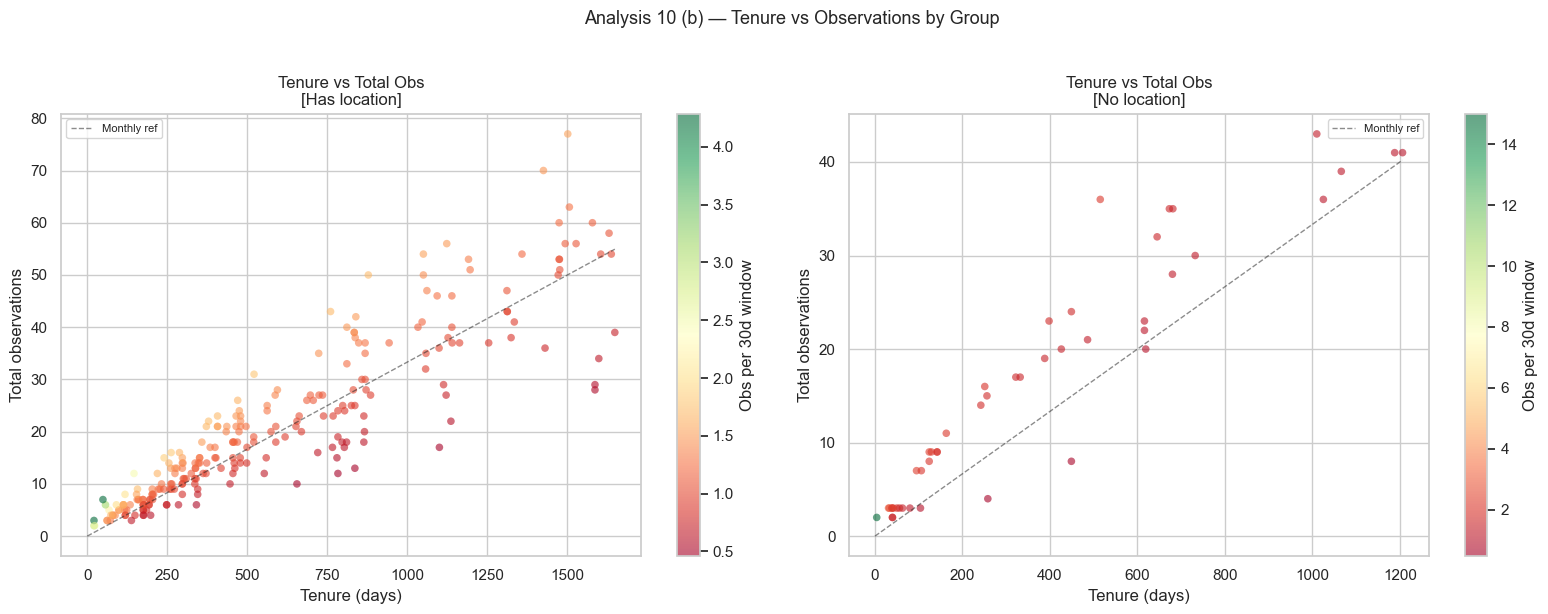

In [23]:
ps = pond_summary.copy()
ps['obs_per_30d'] = np.where(ps['span_days'] > 0,
                              ps['n_obs'] / ps['span_days'] * 30, np.nan)

# ── Overlaid tenure histogram ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for grp in groups:
    sub = ps[ps['location_group'] == grp]
    sns.histplot(sub['span_days'].dropna(), bins=30, kde=True, label=grp,
                 color=LOC_PALETTE[grp], alpha=0.5, ax=ax)
ax.legend()
ax.set_title('Pond Tenure Distribution (overlaid)')
ax.set_xlabel('Days from first to last observation')
ax.set_ylabel('# ponds')

ax = axes[1]
for grp in groups:
    sub = ps[ps['location_group'] == grp]
    sns.histplot(sub['obs_per_30d'].dropna().clip(upper=6), bins=30, kde=True, label=grp,
                 color=LOC_PALETTE[grp], alpha=0.5, ax=ax)
ax.axvline(1.0, color='green', linestyle='--', label='1 obs/30d (monthly)')
ax.legend(fontsize=8)
ax.set_title('Observation Density (obs/30d, capped 6) — overlaid')
ax.set_xlabel('Observations per 30 calendar days (active span)')
ax.set_ylabel('# ponds')

plt.suptitle('Analysis 10 (a) — Tenure and Density: Overlaid', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Separate scatter: tenure vs total observations ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, grp in zip(axes, groups):
    sub = ps[ps['location_group'] == grp]
    color = LOC_PALETTE[grp]
    sc = ax.scatter(sub['span_days'], sub['n_obs'],
                    c=sub['obs_per_30d'], cmap='RdYlGn', alpha=0.6, edgecolors='none', s=30)
    plt.colorbar(sc, ax=ax, label='Obs per 30d window')
    span_ref = np.linspace(0, sub['span_days'].max(), 100)
    ax.plot(span_ref, span_ref / 30, 'k--', linewidth=1, alpha=0.5, label='Monthly ref')
    ax.legend(fontsize=8)
    ax.set_title(f'Tenure vs Total Obs\n[{grp}]')
    ax.set_xlabel('Tenure (days)')
    ax.set_ylabel('Total observations')

plt.suptitle('Analysis 10 (b) — Tenure vs Observations by Group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Analysis 11 — Longest Consecutive Gap per Pond

Max-gap distribution uses overlaid histograms for the two groups. The max-gap vs mean-gap scatter and the ratio category bar chart are shown separately per group.

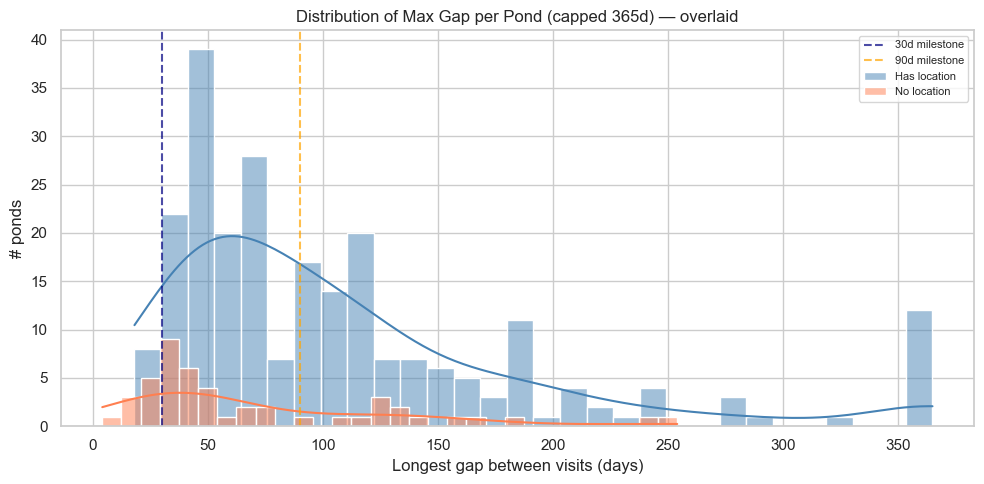

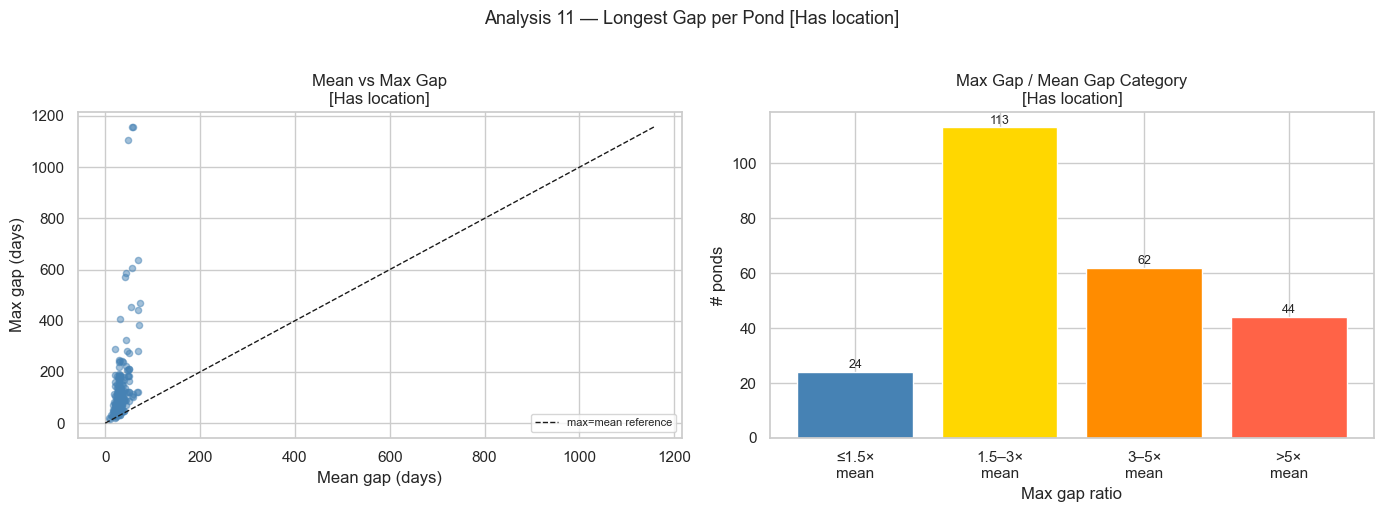

[Has location]  ponds with longest gap >90d: 46.9%


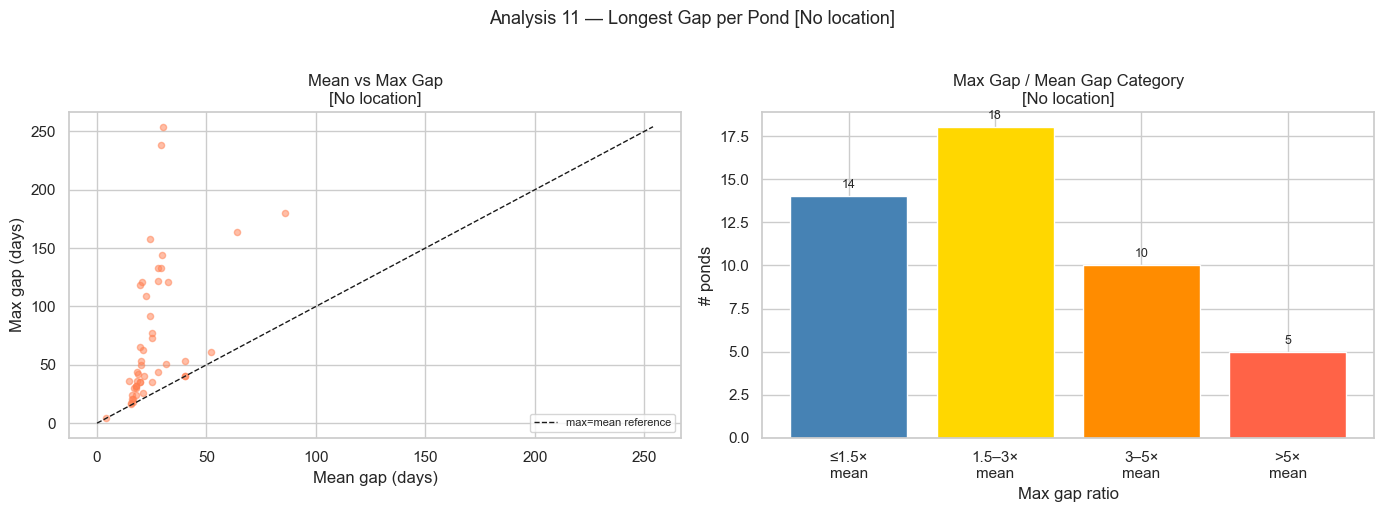

[No location]  ponds with longest gap >90d: 29.8%


In [24]:
multi_obs = pond_summary[pond_summary['n_obs'] >= 2].copy()

# ── Overlaid max-gap histogram ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for grp in groups:
    sub = multi_obs[multi_obs['location_group'] == grp]
    sns.histplot(sub['max_gap'].clip(upper=365), bins=30, kde=True, label=grp,
                 color=LOC_PALETTE[grp], alpha=0.5, ax=ax)
ax.axvline(30,  color='navy',   linestyle='--', alpha=0.7, label='30d milestone')
ax.axvline(90,  color='orange', linestyle='--', alpha=0.7, label='90d milestone')
ax.legend(fontsize=8)
ax.set_title('Distribution of Max Gap per Pond (capped 365d) — overlaid')
ax.set_xlabel('Longest gap between visits (days)')
ax.set_ylabel('# ponds')
plt.tight_layout()
plt.show()

# ── Separate scatter + ratio categories ──────────────────────────────────────
for grp in groups:
    sub = multi_obs[multi_obs['location_group'] == grp].copy()
    color = LOC_PALETTE[grp]
    plot_df = sub.dropna(subset=['mean_gap', 'max_gap'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(plot_df['mean_gap'], plot_df['max_gap'], alpha=0.5, color=color, s=20)
    lim = max(plot_df['mean_gap'].max(), plot_df['max_gap'].max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='max=mean reference')
    ax.set_title(f'Mean vs Max Gap\n[{grp}]')
    ax.set_xlabel('Mean gap (days)')
    ax.set_ylabel('Max gap (days)')
    ax.legend(fontsize=8)

    ax = axes[1]
    plot_df2 = plot_df.copy()
    plot_df2['max_vs_mean'] = plot_df2['max_gap'] / plot_df2['mean_gap']
    cat_labels = ['≤1.5×\nmean', '1.5–3×\nmean', '3–5×\nmean', '>5×\nmean']
    cat_bins   = [0, 1.5, 3, 5, np.inf]
    plot_df2['max_cat'] = pd.cut(plot_df2['max_vs_mean'], bins=cat_bins, labels=cat_labels)
    cat_c = plot_df2['max_cat'].value_counts().reindex(cat_labels)
    ax.bar(cat_labels, cat_c.values, color=['steelblue', 'gold', 'darkorange', 'tomato'])
    ax.set_title(f'Max Gap / Mean Gap Category\n[{grp}]')
    ax.set_xlabel('Max gap ratio')
    ax.set_ylabel('# ponds')
    for i, v in enumerate(cat_c.values):
        if not np.isnan(v):
            ax.text(i, v + 0.3, str(int(v)), ha='center', va='bottom', fontsize=9)

    plt.suptitle(f'Analysis 11 — Longest Gap per Pond [{grp}]', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    over90 = (sub['max_gap'] > 90).mean() * 100
    print(f"[{grp}]  ponds with longest gap >90d: {over90:.1f}%")

## Analysis 12 — When Do Ponds Enter the Dataset? (Cohort Entry over Time)

Separate entry/exit timeline plots for each location group.

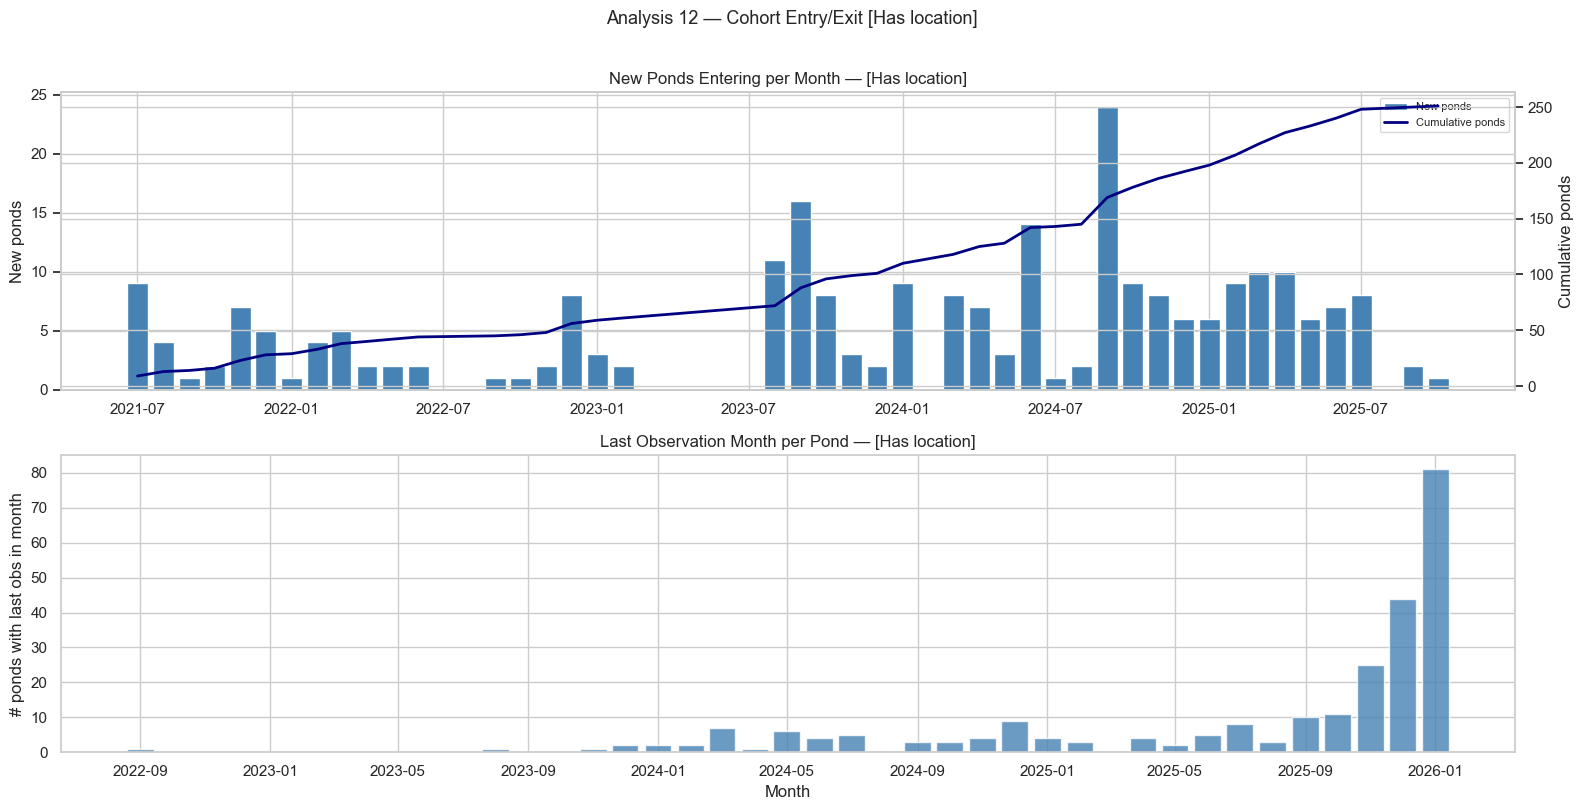

[Has location]  total=251 ponds  peak entry: 2024-09 (24 ponds)


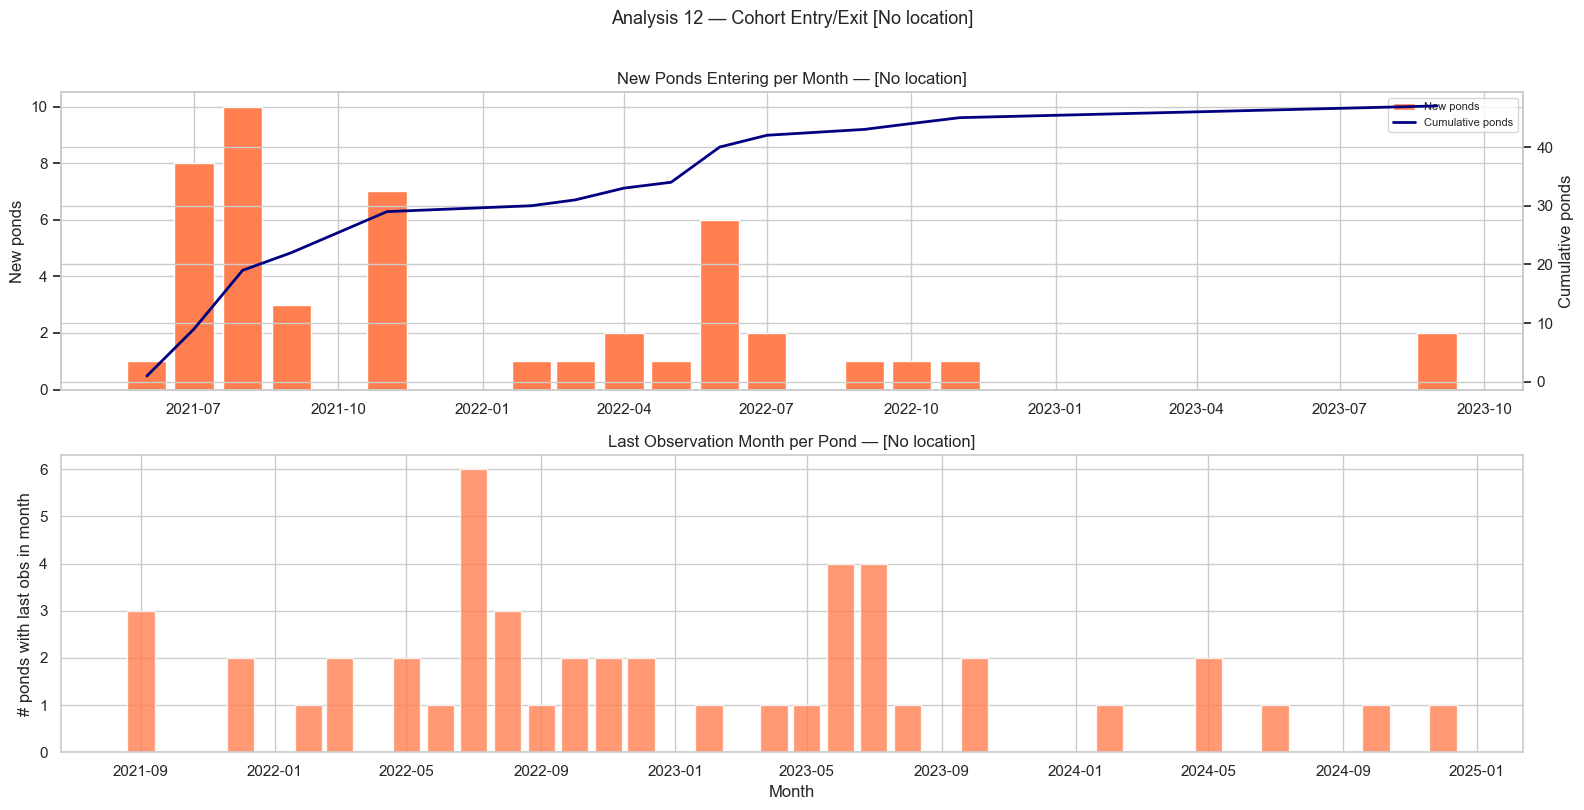

[No location]  total=47 ponds  peak entry: 2021-08 (10 ponds)


In [25]:
pond_summary['first_month'] = pond_summary['first_date'].dt.to_period('M')
pond_summary['last_month']  = pond_summary['last_date'].dt.to_period('M')

for grp in groups:
    ps_grp = pond_summary[pond_summary['location_group'] == grp]
    color  = LOC_PALETTE[grp]

    entry = ps_grp.groupby('first_month').size().reset_index(name='new_ponds')
    entry['month_dt']  = entry['first_month'].dt.to_timestamp()
    entry['cum_ponds'] = entry['new_ponds'].cumsum()

    exit_ = ps_grp.groupby('last_month').size().reset_index(name='last_obs_ponds')
    exit_['month_dt'] = exit_['last_month'].dt.to_timestamp()

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    ax = axes[0]
    ax.bar(entry['month_dt'], entry['new_ponds'], width=25, color=color, label='New ponds')
    ax2 = ax.twinx()
    ax2.plot(entry['month_dt'], entry['cum_ponds'], color='navy', linewidth=2,
             label='Cumulative ponds')
    ax2.set_ylabel('Cumulative ponds')
    ax.set_title(f'New Ponds Entering per Month — [{grp}]')
    ax.set_ylabel('New ponds')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8)

    ax = axes[1]
    ax.bar(exit_['month_dt'], exit_['last_obs_ponds'], width=25, color=color, alpha=0.8)
    ax.set_title(f'Last Observation Month per Pond — [{grp}]')
    ax.set_ylabel('# ponds with last obs in month')
    ax.set_xlabel('Month')

    plt.suptitle(f'Analysis 12 — Cohort Entry/Exit [{grp}]', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"[{grp}]  total={len(ps_grp)} ponds  "
          f"peak entry: {entry.loc[entry.new_ponds.idxmax(),'first_month']} "
          f"({entry['new_ponds'].max()} ponds)")

## Analysis 13 — Regularity Variation by Quarter

Does within-quarter scheduling regularity change over time, and does it differ between location groups? Separate box-plot + median-trend pairs.

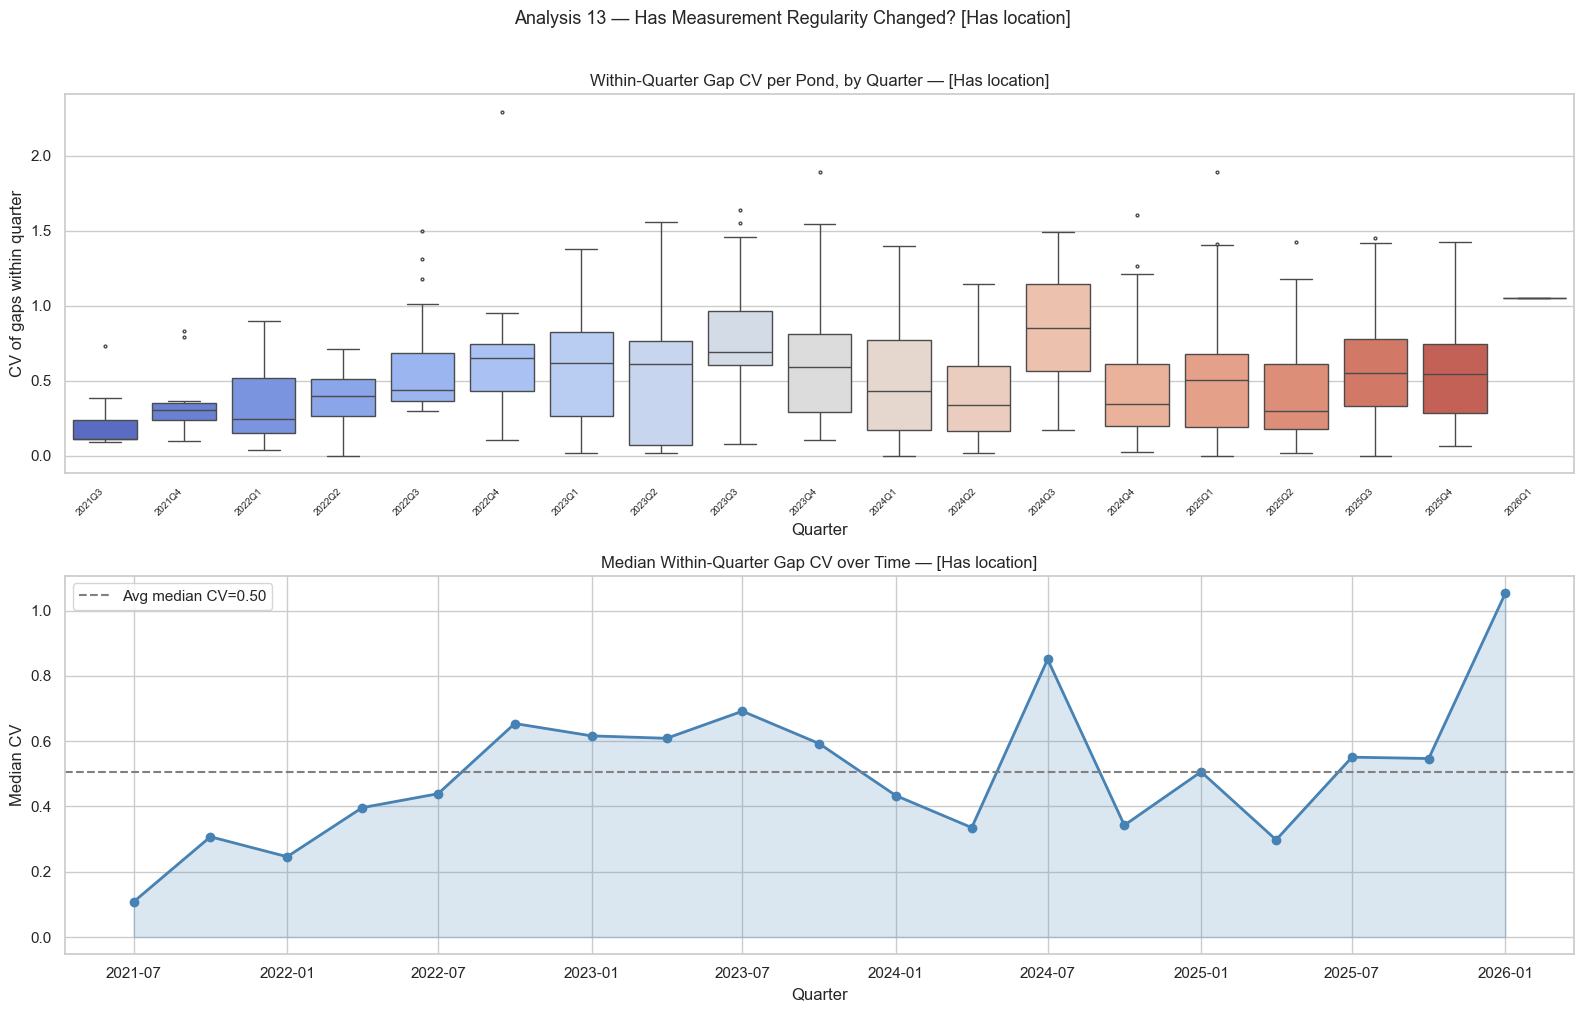

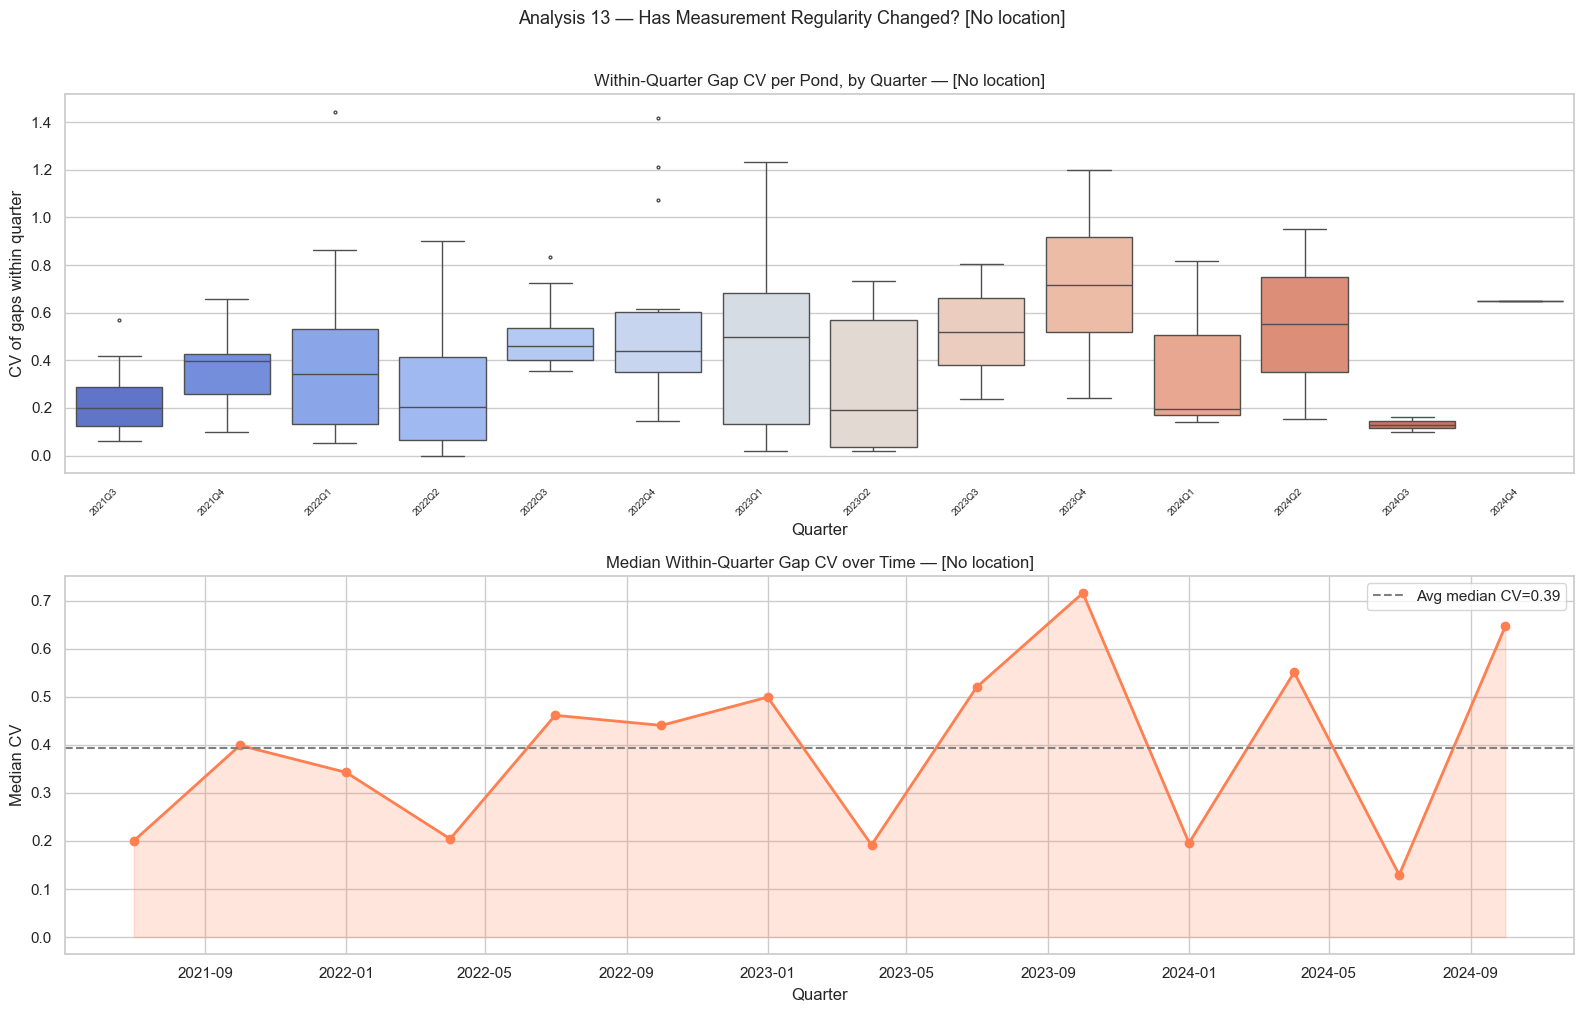

In [26]:
q_gaps_df = gaps.copy()
q_gaps_df['quarter'] = q_gaps_df['date'].dt.to_period('Q')

def quarter_cv(g):
    if len(g) < 3 or g['gap_days'].mean() == 0:
        return np.nan
    return g['gap_days'].std() / g['gap_days'].mean()

q_reg_all = (q_gaps_df.groupby(['location_group', 'quarter', 'pond_id'])
             .apply(quarter_cv, include_groups=False)
             .reset_index(name='q_cv')
             .dropna(subset=['q_cv']))
q_reg_all['q_label'] = q_reg_all['quarter'].astype(str)

for grp in groups:
    q_reg = q_reg_all[q_reg_all['location_group'] == grp]
    if q_reg.empty:
        continue
    color = LOC_PALETTE[grp]

    order = sorted(q_reg['q_label'].unique())

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    ax = axes[0]
    sns.boxplot(data=q_reg, x='q_label', y='q_cv', order=order, hue='q_label',
                palette='coolwarm', ax=ax,
                flierprops=dict(markersize=2), legend=False)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_title(f'Within-Quarter Gap CV per Pond, by Quarter — [{grp}]')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('CV of gaps within quarter')

    ax = axes[1]
    med_cv = q_reg.groupby('quarter')['q_cv'].median().reset_index()
    med_cv['q_dt'] = med_cv['quarter'].dt.to_timestamp()
    ax.plot(med_cv['q_dt'], med_cv['q_cv'], marker='o', color=color, linewidth=2)
    ax.fill_between(med_cv['q_dt'], med_cv['q_cv'], alpha=0.2, color=color)
    ax.axhline(med_cv['q_cv'].mean(), color='grey', linestyle='--',
               label=f'Avg median CV={med_cv["q_cv"].mean():.2f}')
    ax.set_title(f'Median Within-Quarter Gap CV over Time — [{grp}]')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Median CV')
    ax.legend()

    plt.suptitle(f'Analysis 13 — Has Measurement Regularity Changed? [{grp}]',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## Analysis 14 — Cumulative Observations for Top Ponds Over Time

Top 10 ponds from each group shown in separate figures: cumulative observation step chart and visit timeline scatter.

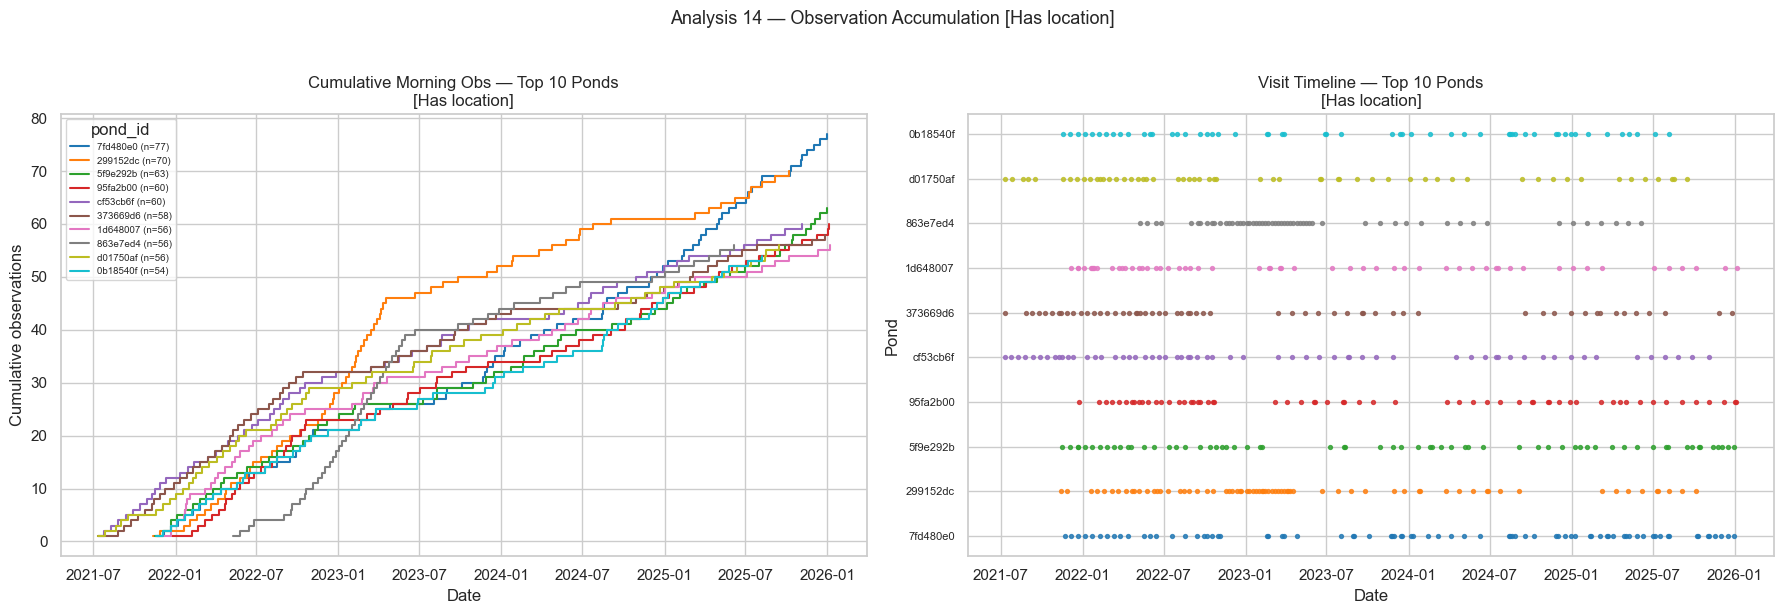

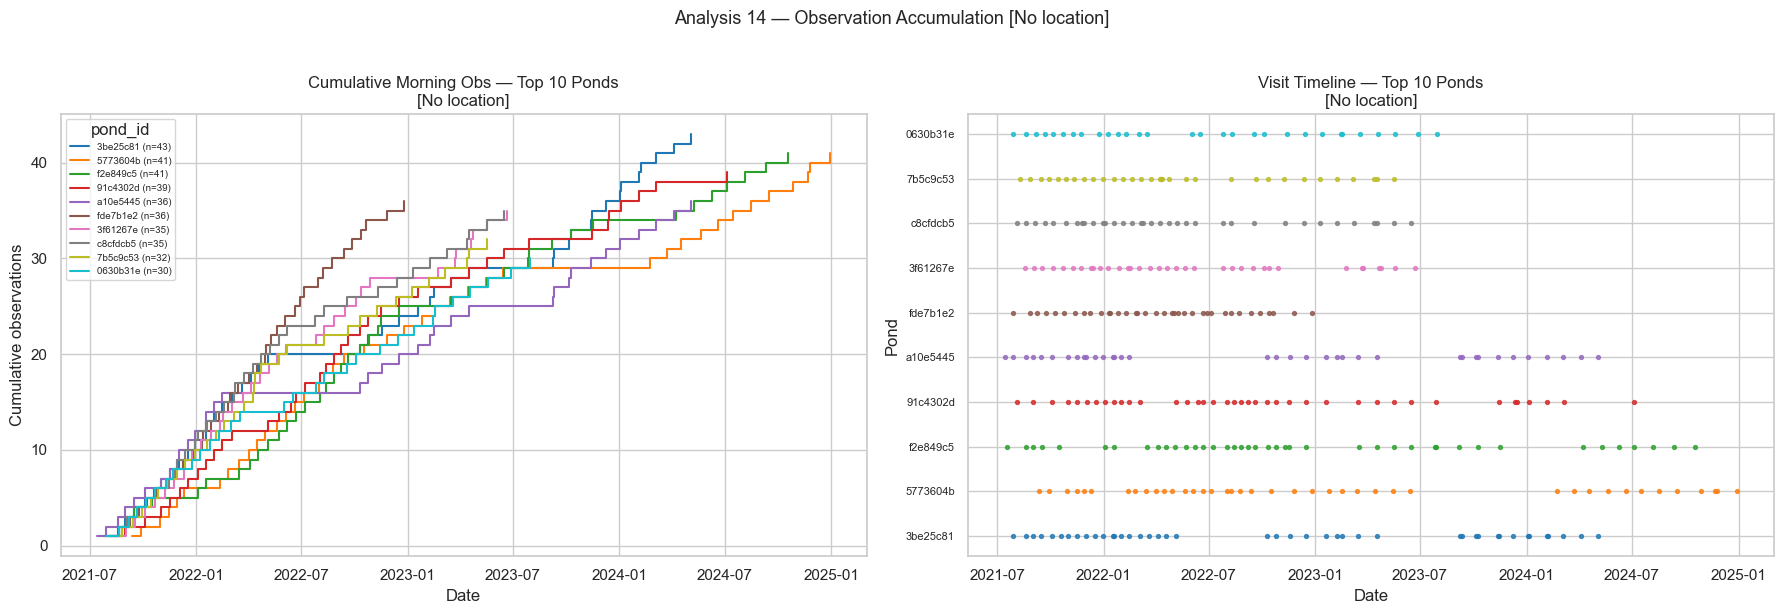

In [27]:
colors_top = sns.color_palette('tab10', n_colors=10)

for grp in groups:
    ps_grp  = pond_summary[pond_summary['location_group'] == grp]
    top10   = ps_grp.nlargest(min(10, len(ps_grp)), 'n_obs')['pond_id'].tolist()
    m_grp   = morning[(morning['pond_id'].isin(top10)) &
                      (morning['location_group'] == grp)].sort_values('date')

    if not top10:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    ax = axes[0]
    for i, pid in enumerate(top10):
        sub = m_grp[m_grp['pond_id'] == pid].sort_values('date')
        sub = sub.assign(cum_obs=range(1, len(sub) + 1))
        ax.step(sub['date'], sub['cum_obs'], where='post',
                color=colors_top[i % 10], linewidth=1.5,
                label=f"{pid[-8:]} (n={len(sub)})")
    ax.legend(fontsize=7, title='pond_id', loc='upper left')
    ax.set_title(f'Cumulative Morning Obs — Top {len(top10)} Ponds\n[{grp}]')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative observations')

    ax = axes[1]
    for i, pid in enumerate(top10):
        sub = m_grp[m_grp['pond_id'] == pid]
        ax.scatter(sub['date'], [i] * len(sub), color=colors_top[i % 10], s=8, alpha=0.8)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels([p[-8:] for p in top10], fontsize=8)
    ax.set_title(f'Visit Timeline — Top {len(top10)} Ponds\n[{grp}]')
    ax.set_xlabel('Date')
    ax.set_ylabel('Pond')

    plt.suptitle(f'Analysis 14 — Observation Accumulation [{grp}]', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## Analysis 15 — Month-over-Month Pond Retention

Retention rate trends and stacked returning/new bars shown separately for each location group.

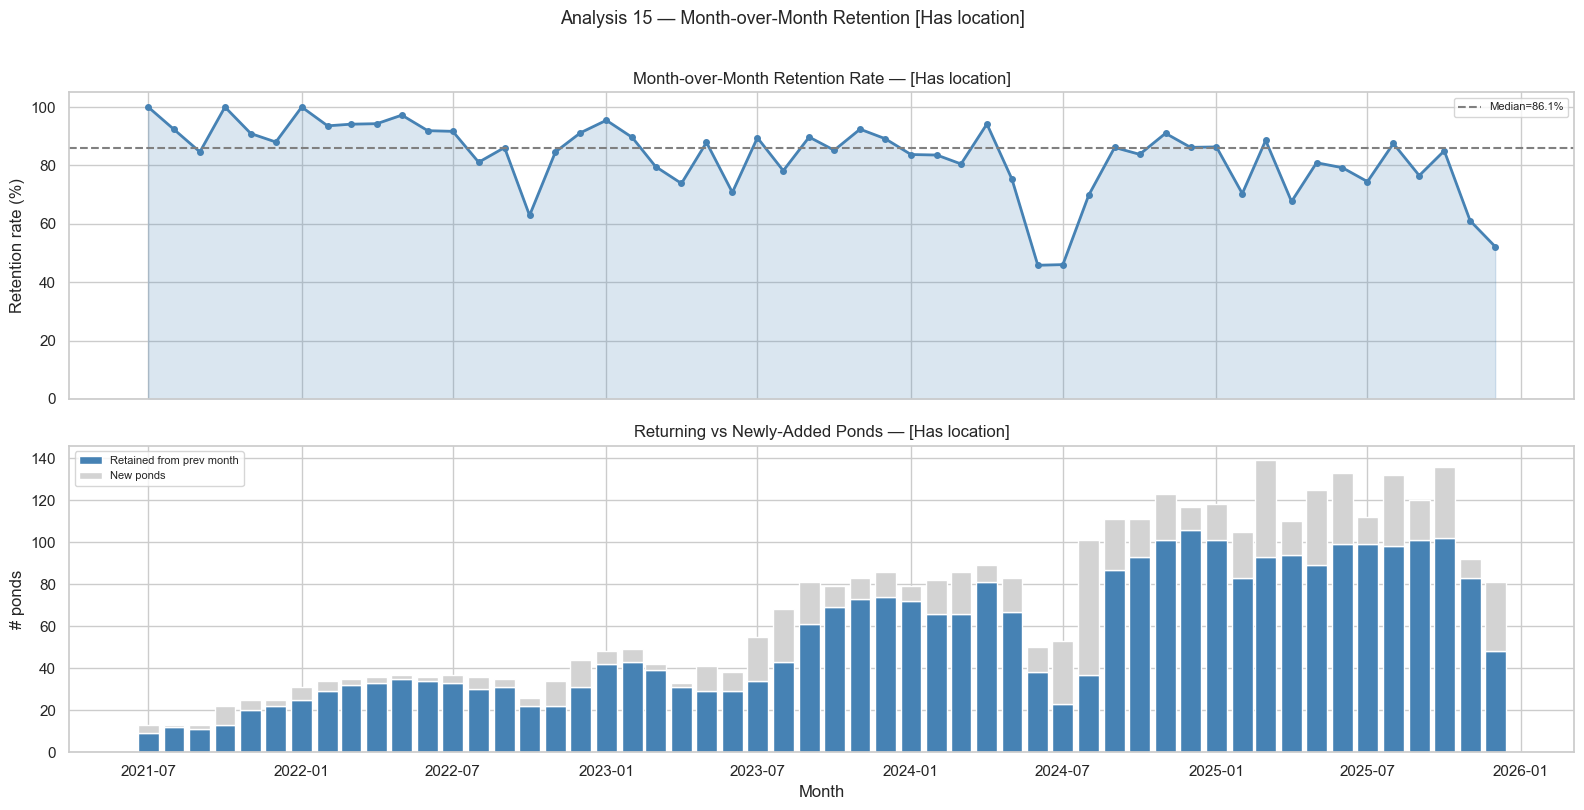

[Has location]  median retention=86.1%  min=45.8% (2024-06)  max=100.0% (2021-07)


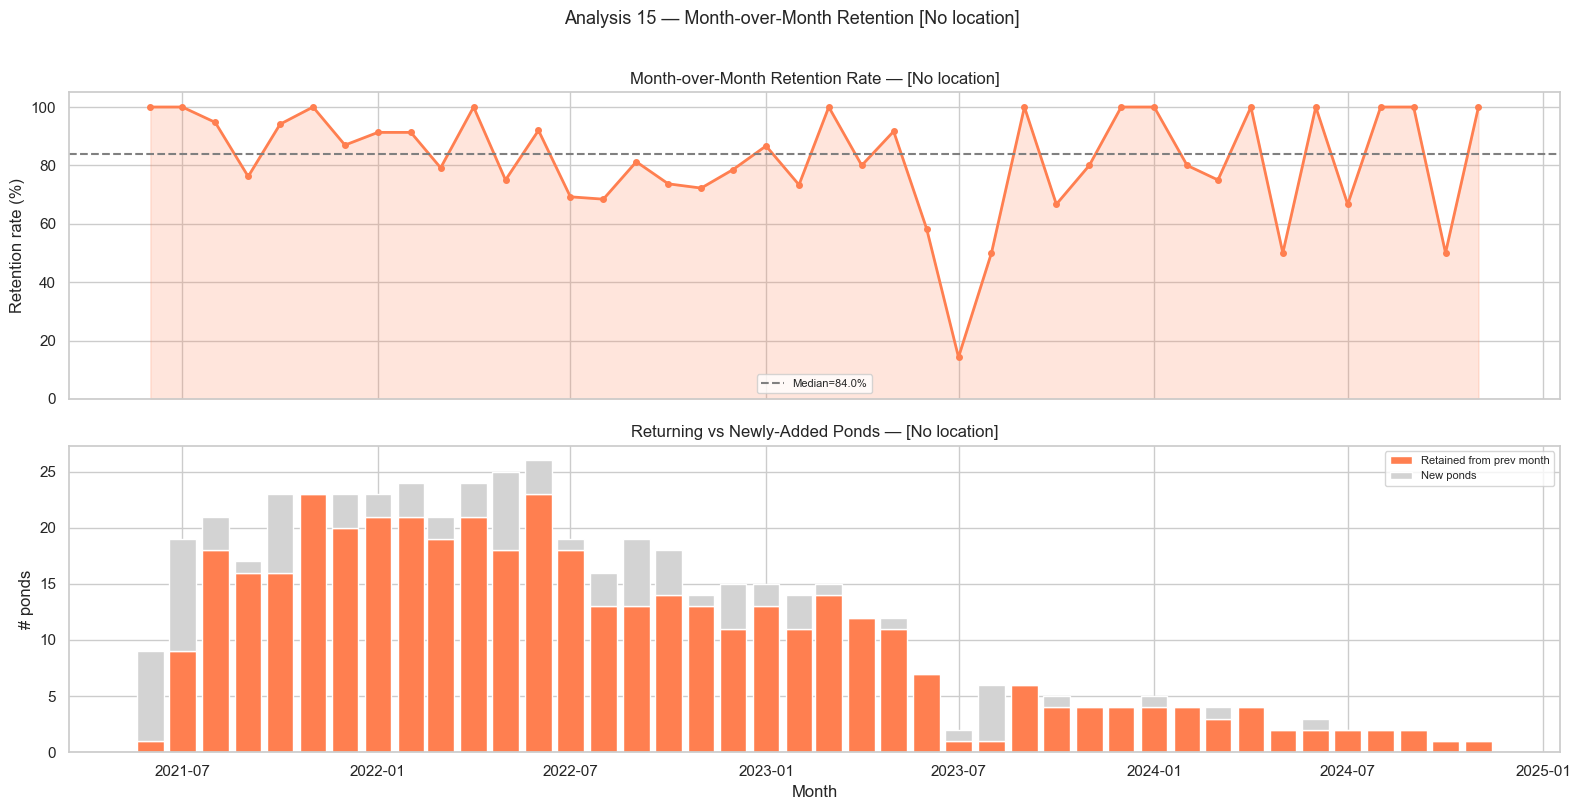

[No location]  median retention=84.0%  min=14.3% (2023-07)  max=100.0% (2021-06)


In [28]:
for grp in groups:
    m_grp  = morning[morning['location_group'] == grp]
    color  = LOC_PALETTE[grp]

    month_ponds   = m_grp.groupby('month')['pond_id'].apply(set)
    sorted_months = sorted(month_ponds.index)

    retention_rows = []
    for i in range(len(sorted_months) - 1):
        m0, m1 = sorted_months[i], sorted_months[i + 1]
        s0, s1 = month_ponds[m0], month_ponds[m1]
        if (m1 - m0).n == 1:
            retained = len(s0 & s1)
            new_in_m1 = len(s1 - s0)
            retention_rows.append({
                'month':          m0,
                'month_dt':       m0.to_timestamp(),
                'n_ponds_this':   len(s0),
                'n_retained_next': retained,
                'n_new_next':     new_in_m1,
                'retention_rate': retained / len(s0) if s0 else np.nan,
            })

    if not retention_rows:
        print(f"[{grp}] — no consecutive month pairs")
        continue

    ret_df = pd.DataFrame(retention_rows)

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    ax = axes[0]
    ax.plot(ret_df['month_dt'], ret_df['retention_rate'] * 100,
            color=color, linewidth=2, marker='o', markersize=4)
    ax.fill_between(ret_df['month_dt'], ret_df['retention_rate'] * 100, alpha=0.2, color=color)
    med_ret = ret_df['retention_rate'].median() * 100
    ax.axhline(med_ret, color='grey', linestyle='--', label=f'Median={med_ret:.1f}%')
    ax.set_ylim(0, 105)
    ax.set_title(f'Month-over-Month Retention Rate — [{grp}]')
    ax.set_ylabel('Retention rate (%)')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.bar(ret_df['month_dt'], ret_df['n_retained_next'], width=25,
           color=color, label='Retained from prev month')
    ax.bar(ret_df['month_dt'], ret_df['n_new_next'], width=25,
           bottom=ret_df['n_retained_next'], color='lightgrey', label='New ponds')
    ax.set_title(f'Returning vs Newly-Added Ponds — [{grp}]')
    ax.set_ylabel('# ponds')
    ax.set_xlabel('Month')
    ax.legend(fontsize=8)

    plt.suptitle(f'Analysis 15 — Month-over-Month Retention [{grp}]', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    min_r = ret_df.loc[ret_df.retention_rate.idxmin()]
    max_r = ret_df.loc[ret_df.retention_rate.idxmax()]
    print(f"[{grp}]  median retention={med_ret:.1f}%  "
          f"min={min_r.retention_rate*100:.1f}% ({min_r.month})  "
          f"max={max_r.retention_rate*100:.1f}% ({max_r.month})")